# EDIS 8100 · Week 5 · Mini Project 2: Whose Writing Gets Called Effective?

### Text-Based Analytics and Natural Language Processing on 5,531 Real Student Essays

**Fall 2026 · Dr. Hakeoung Hannah Lee · University of Virginia**

We open this notebook together in class on Wednesday, September 23, 2026, from 3:30 to 4:20 PM. Our guest, Jiayi (Joyce) Zhang of Worcester Polytechnic Institute, speaks from 4:30 to 5:30, and the block from 5:30 to 5:50 is a debrief with time to return to this notebook. If you would like more time after that, you are welcome to keep working on your own before the Canvas deadline. There is no student-led discussion block this week.

### What is submitted, and what is assessed

This is Mini Project 2, so the notebook is submitted. Your executed copy goes to Canvas by **11:59 PM on Sunday, September 27, 2026**, together with the interpretation memo written in the cell near the end and your AI interaction log and reflection.

Coding skill is not what is assessed. Every code cell here already contains working code, and there is no expectation that you write any from scratch, this week or in any other week of the course. **The interpretation memo is the primary component used for grading.** Your attention is best spent on what the code is doing to the data and on what the output might mean.

Questions are welcome at any point, including questions about a single line of code.

---

## Learning objectives

By the end of this notebook you will be able to:

1. **Build** a text analysis pipeline on real student writing: clean, tokenize, count, and say out loud what each cleaning decision deleted from the record.
2. **Score** stance with a lexicon small enough to read in full, then compare what it explains about a human's judgment against the crudest feature in the file.
3. **Fit and compare** two topic models (NMF and LDA), interpret their topics against four known writing prompts, and consider why a topic model that performs this well here may be less reassuring than it looks.
4. **Train and audit** a bag-of-words classifier against 55,068 spans of human-annotated ground truth: where it succeeds, where it collapses, and what its errors suggest about the construct.
5. **Disaggregate** both the human ratings and the model's errors by writer group, and discuss what the pattern might mean without pretending the data settles it.

Objectives 2 and 3 belong to sections completed at home before submission; the route box below says which.


---

## What is different about this week

Records of behavior, such as clicks, grades, submissions and outcomes, report what a registry wrote down about a person. This one is a record of **judgment**.

A registry record holds no second person's opinion of the work itself, so a model built on it cannot be checked against one. This corpus carries such an opinion for every span, and much of what is difficult about the week follows from that.

So this week you work on **5,531 essays written by United States students in grades 8 through 12**, carrying **63,211 stretches of text that human beings marked one at a time**. 55,070 of those were named as a specific argumentative move, and 55,068 of *those* also carry a human rating of how well the move worked. The remaining 8,141 are the text the annotators did not assign to any move, and they come up again in Section 6. Columns are blank. Words are misspelled. One third of the corpus is missing two demographic fields entirely, and every missing row is in one prompt. Section 7 disaggregates the human ratings by writer classification.



## How to work through this notebook

- Run cells **top to bottom**. Click a cell, then press **Shift + Enter**. Cells lower down depend on the ones above them.
- The notebook runs on a temporary machine in the cloud, working on a copy of a published corpus. It only reads data, so nothing you do here changes the corpus or the course repository. In Colab, **File > Save a copy in Drive** keeps a personal version, and that copy is the one you submit.
- If something goes wrong, **Runtime > Restart session and run all** resolves almost everything.
- Cells marked **Your turn** already hold a working value. You can run the whole notebook without editing anything and nothing will be missing. Changing one and re-running makes visible what that choice was doing to the result.
- Sections marked **Going further (optional)** sit outside the core path. Please feel free to skip them.
- Questions are welcome at any point.

### The route for today

| | Sections |
|---|---|
| **CORE, about 55 to 60 minutes** | Setup; 1. Meet the corpus; 2. Cleaning and tokenizing, through the stoplist check; 6. Human ground truth; 7. Whose writing gets called effective? |
| **IF TIME** | Your turn 1; 3. Word frequencies; Your turn 4 |
| **EXPLORE LATER, at home before the Sunday deadline** | 4. A stance lexicon and Your turn 2; 5. Topic modeling and Your turn 3; the reflection and the memo; 8. Going further and Your turn 5 (optional); the appendix |

This is a mini project, so EXPLORE LATER means completed at home before submission: the checklist requires all five Your turn cells, and Sections 4 and 5 carry two of them. Section 8 is optional.


**Where the graded thinking sits.** Editing the code is not what is being assessed. Running the cells as written and writing a careful reading of the output is the assignment, and the interpretation memo near the end is the primary component used for grading.

**If you work in R, SPSS, or Stata, or have not written code before,** you might find it useful to read the code the way you read a methods section: you are checking what was done to the data, not memorizing syntax. Two patterns cover most of it. Square brackets after a table, as in `df[df.score > 50]`, select a subset, like `subset()` or a filter. A line ending in `.mean()`, `.sum()`, or `.value_counts()` summarizes, like `aggregate()` or a frequency table. When a line does not make sense, please ask.

---

## Setup: where this data comes from



### The dataset

**PERSUADE 2.0** (Persuasive Essays for Rating, Selecting, and Understanding Argumentative and Discourse Elements). A corpus of argumentative essays written by students in grades 6 through 12 in the United States, for 15 prompts across two writing tasks, independent and source-based. That is what the corpus documentation states about its origin; it does not name the schools, districts, or assessment programs the essays came from. Each essay carries a **holistic score from 1 to 6** assigned by trained human raters, and each essay was then read again by human annotators who marked the **boundaries of every argumentative move in it** (the lead, the position, each claim, each counterclaim, each rebuttal, each piece of evidence, the conclusion) and rated each of those moves **Effective, Adequate, or Ineffective**.

That second layer is the reason for using this corpus. Somebody sat down and marked 63,211 stretches of teenage writing, named 55,070 of them as a specific argumentative move, and rated 55,068 of those one at a time. Those judgments are the ground truth you will check your models against.

### What we are using

The full corpus covers 15 prompts and grades 6 through 12. This notebook uses a **four-prompt subset of 5,531 essays**, written by students in grades 8 through 12, hosted for this course at `github.com/HakeoungLee/edis8100-datasets`. Nothing was altered except the selection of prompts and the packaging.

### License and terms

**CC BY-NC-SA 4.0.** Attribution, non-commercial use only, share-alike. Coursework is fine. Building a product on it is not.

### How to cite it

> Crossley, S. A., Baffour, P., Tian, Y., Franklin, A., Benner, M., & Boser, U. (2024). A large-scale corpus for assessing written argumentation: PERSUADE 2.0. *Assessing Writing, 61*, 100865. https://doi.org/10.1016/j.asw.2024.100865

### Origin

Real students in grades 8 through 12 wrote to a set prompt about driverless cars, cell phone policy, distance learning, and the Electoral College. Researchers obtained those essays, hired human raters to score them and human annotators to label every argumentative move inside them, stripped the names, and released the result openly so that people like us could study writing without having to run our own assessment. Exactly which writing programs the essays were drawn from is not stated in the release.

**Producing this file took thousands of students' school assignments, thousands of hours of human rating, and a legal and ethical release process.**

**Run the cell below.** It fetches two files over the internet. Nothing is installed on your computer and nothing is saved to it.

In [1]:
# ============================================================================
# Load this week's data from the course dataset repository. No downloads to
# your computer, no logins, no API keys. Takes about a second.
# ============================================================================
import pandas as pd

BASE = "https://raw.githubusercontent.com/HakeoungLee/edis8100-datasets/main"

try:
    essays = pd.read_csv(f"{BASE}/persuade-4prompts/essays.csv.gz")
    spans = pd.read_csv(f"{BASE}/persuade-4prompts/discourse_elements.csv.gz")
except Exception:
    print("=" * 78)
    print("The data did not download, and that is usually the network.")
    print("Here is what to check, in order:")
    print()
    print("  1. Are you online? Reload any web page to be sure.")
    print("  2. Try running this cell again. Transient failures are common.")
    print("  3. Confirm the dataset repository is reachable in a browser tab:")
    print("     https://github.com/HakeoungLee/edis8100-datasets")
    print("  4. If you are on a locked-down campus or hospital network, it may")
    print("     be blocking raw.githubusercontent.com. Try a different network,")
    print("     or run this notebook in Google Colab instead.")
    print()
    print("If it is still failing after all four, post on Canvas with a")
    print("screenshot.")
    print("=" * 78)
    raise RuntimeError(
        "Could not download the PERSUADE data from edis8100-datasets. "
        "See the message printed above."
    ) from None

print("Data arrived. Here is what you have.")
print()
print(f"  essays.csv.gz              {essays.shape[0]:>6,} essays  x {essays.shape[1]:>2} columns")
print(f"  discourse_elements.csv.gz  {spans.shape[0]:>6,} spans   x {spans.shape[1]:>2} columns")
print()
print(f"  Written by students in grades {int(essays['grade_level'].min())} "
      f"through {int(essays['grade_level'].max())}.")
print(f"  {essays['prompt_name'].nunique()} writing prompts. "
      f"{essays['essay_word_count'].sum():,} words of student writing in total.")
print(f"  {spans['discourse_effectiveness'].notna().sum():,} of the spans carry a "
      f"human rating of how well the move worked.")
print()
print("PERSUADE 2.0, CC BY-NC-SA 4.0. Crossley et al. (2024), Assessing Writing 61.")

Data arrived. Here is what you have.

  essays.csv.gz               5,531 essays  x 13 columns
  discourse_elements.csv.gz  63,211 spans   x  8 columns

  Written by students in grades 8 through 12.
  4 writing prompts. 2,470,005 words of student writing in total.
  55,068 of the spans carry a human rating of how well the move worked.

PERSUADE 2.0, CC BY-NC-SA 4.0. Crossley et al. (2024), Assessing Writing 61.


**Run the cell below** for the tools, all of them already installed in Colab: **pandas** for tables, **numpy** for arrays and arithmetic, **matplotlib** for figures, and **scikit-learn** for the vectorizers, the two topic models, and the classifiers. There is nothing to install.

In [2]:
%matplotlib inline

import re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import NMF, LatentDirichletAllocation
from sklearn.metrics import (adjusted_rand_score, accuracy_score, f1_score,
                             recall_score, classification_report)
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

pd.set_option('display.width', 170)
pd.set_option('display.max_colwidth', 90)
plt.rcParams.update({
    'figure.dpi': 110,
    'figure.autolayout': True,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

RANDOM_STATE = 8100      # the course seed, so your numbers match your classmates'

# A colorblind-safe palette (Paul Tol's bright set). Nothing here relies on
# telling red from green.
BLUE, ROSE, GREEN, YELLOW, CYAN, PURPLE, GREY = (
    '#4477AA', '#EE6677', '#228833', '#CCBB44', '#66CCEE', '#AA3377', '#BBBBBB')

# Short names for the four prompts, because the real ones are paragraphs long.
PROMPT_SHORT = {
    'Does the electoral college work?': 'electoral college',
    'Distance learning': 'distance learning',
    'Driverless cars': 'driverless cars',
    'Cell phones at school': 'cell phones',
}
essays['prompt_short'] = essays['prompt_name'].map(PROMPT_SHORT)

print('Libraries loaded. Random seed:', RANDOM_STATE)
print('Prompts, shortened for readability:')
for long, short in PROMPT_SHORT.items():
    print(f'   {short:<20} <- "{long[:52]}..."')

Libraries loaded. Random seed: 8100
Prompts, shortened for readability:
   electoral college    <- "Does the electoral college work?..."
   distance learning    <- "Distance learning..."
   driverless cars      <- "Driverless cars..."
   cell phones          <- "Cell phones at school..."


---

## 1. Meet the corpus

The first job is to know how much writing there is, who is in it, and who is missing.

There are two files at two grain sizes. `essays` has **one row per essay**. `spans` has **one row per argumentative move inside an essay**, so a single essay contributes many rows. 

**Run the cell below.**

In [3]:
print('ESSAYS: one row per essay')
print('  shape:', essays.shape)
print('  columns:', list(essays.columns))
print()
print('SPANS: one row per argumentative move inside an essay')
print('  shape:', spans.shape)
print('  columns:', list(spans.columns))
print()
print(f'  So the average essay contributes {len(spans) / len(essays):.2f} spans, '
      f'and {spans["essay_id"].nunique():,} of the {len(essays):,} essays have at least one.')
print()
print('The four prompts, and what they asked for:')
overview = essays.groupby('prompt_short').agg(
    essays=('essay_id', 'size'),
    task_type=('task', 'first'),
    mean_score=('holistic_essay_score', 'mean'),
    mean_words=('essay_word_count', 'mean'),
).round(2).sort_values('essays', ascending=False)
print(overview.to_string())
print()
print('Grade levels represented:')
print(essays['grade_level'].astype(int).value_counts().sort_index().to_string())
print()
print('Essay length, in words:')
print(essays['essay_word_count'].describe().round(1).to_string())
print()
print('Grade level by prompt (each prompt was answered by a different grade level):')
print(pd.crosstab(essays['prompt_short'], essays['grade_level'].astype(int)).to_string())
print()
print('What each prompt asked for, from the assignment column:')
for p, a in essays.groupby('prompt_short')['assignment'].first().items():
    print(f'  {p}: {a}')


ESSAYS: one row per essay
  shape: (5531, 14)
  columns: ['essay_id', 'prompt_name', 'task', 'assignment', 'holistic_essay_score', 'essay_word_count', 'grade_level', 'gender', 'ell_status', 'race_ethnicity', 'economically_disadvantaged', 'student_disability_status', 'full_text', 'prompt_short']

SPANS: one row per argumentative move inside an essay
  shape: (63211, 8)
  columns: ['essay_id', 'discourse_id', 'discourse_start', 'discourse_end', 'discourse_type', 'discourse_type_num', 'discourse_effectiveness', 'discourse_text']

  So the average essay contributes 11.43 spans, and 5,531 of the 5,531 essays have at least one.

The four prompts, and what they asked for:
                   essays       task_type  mean_score  mean_words
prompt_short                                                     
electoral college    1818  Text dependent        3.01      431.15
distance learning    1498     Independent        4.41      586.32
driverless cars      1386  Text dependent        3.20      402

**Let's look at the output.**

**"Text dependent" versus "Independent" matters.** The `task` column marks two prompts (electoral college, driverless cars) as text dependent, and their `assignment` text tells the writer to use the source texts. The other two do not. Those are different writing tasks, and any word-level comparison across them is partly a comparison of the source articles the students were handed.

**The prompts have very different mean scores.** Distance learning averages 4.41 and the electoral college prompt averages 3.01. That is a fact about the essays and the raters before it is a fact about students, Each prompt was answered by a different grade level (the crosstab above), so a comparison across prompts is also a comparison across grades, and this file cannot separate prompt, grade, and whatever else differed between the sources.

**The prompts have very different mean lengths too:** 586 words for distance learning, 302 for cell phones. 

**Run the cell below** for the same information as a figure.

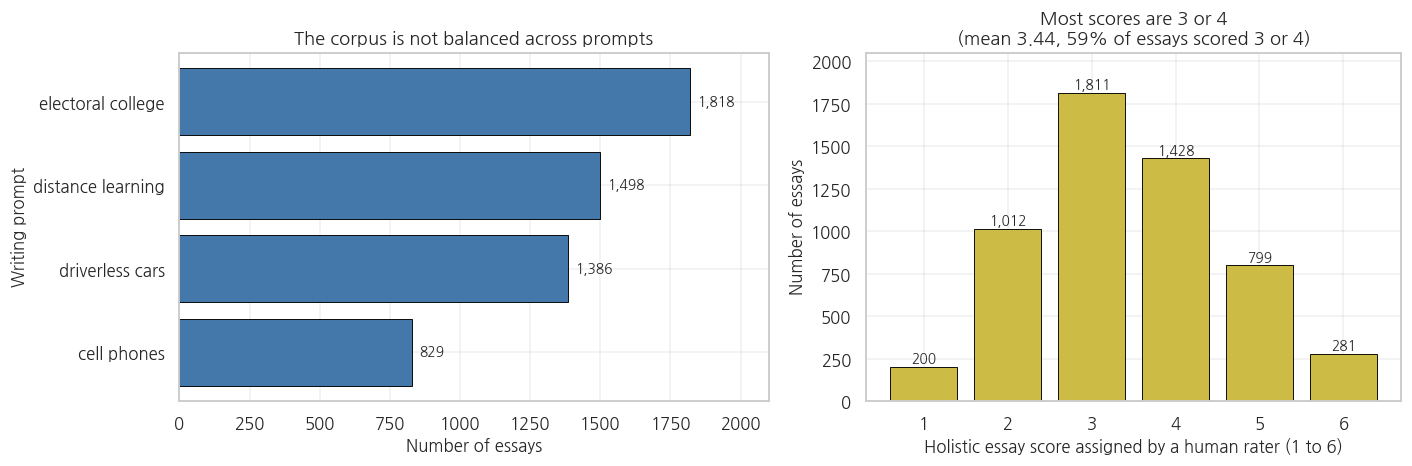

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={'width_ratios': [1.1, 1]})

# Panel 1: essays per prompt
counts = essays['prompt_short'].value_counts().sort_values()
axes[0].barh(counts.index, counts.values, color=BLUE, edgecolor='black', linewidth=0.6)
for y, v in enumerate(counts.values):
    axes[0].text(v + 25, y, f'{v:,}', va='center', fontsize=9)
axes[0].set_xlabel('Number of essays')
axes[0].set_ylabel('Writing prompt')
axes[0].set_title('The corpus is not balanced across prompts')
axes[0].set_xlim(0, 2100)

# Panel 2: holistic score distribution
dist = essays['holistic_essay_score'].value_counts().sort_index()
axes[1].bar(dist.index, dist.values, color=YELLOW, edgecolor='black', linewidth=0.6)
for x, v in zip(dist.index, dist.values):
    axes[1].text(x, v + 25, f'{v:,}', ha='center', fontsize=9)
axes[1].set_xlabel('Holistic essay score assigned by a human rater (1 to 6)')
axes[1].set_ylabel('Number of essays')
axes[1].set_title(f'Most scores are 3 or 4\n(mean {essays["holistic_essay_score"].mean():.2f}, '
                  f'{(dist.loc[3] + dist.loc[4]) / len(essays):.0%} of essays scored 3 or 4)')
axes[1].set_xticks(list(dist.index))
axes[1].set_ylim(0, 2050)

plt.show()

**Let's look at the output.**

The left panel: the electoral college prompt supplies 1,818 essays and the cell phone prompt supplies 829, so the corpus holds more than twice as much of one as of the other. Any model fit on all four at once weights most heavily the prompt with the most essays, which is worth reporting rather than trying to correct.

The right panel: 3,239 of the 5,531 essays, 59 percent, were scored 3 or 4. Only 200 essays received a 1 and only 281 received a 6. A measure that puts most of its mass in two adjacent categories has less room to distinguish people than its six-point range suggests. 



### Missing data

Three of the columns describing who wrote these essays are incomplete, and the incompleteness is not spread randomly across the file.

**Run the cell below**, and look at *where* the missing values are.

In [5]:
demographics = ['gender', 'race_ethnicity', 'ell_status',
                'economically_disadvantaged', 'student_disability_status']

report = []
for col in demographics:
    blank = essays[col].isna().sum() + (essays[col].astype(str).str.strip() == '').sum()
    report.append({'column': col, 'missing or blank': blank,
                   'percent of corpus': round(100 * blank / len(essays), 1)})
print('Who is described, and who is not:')
print(pd.DataFrame(report).to_string(index=False))
print()

print('Now the same question, by prompt:')
holes = pd.DataFrame({
    'essays': essays.groupby('prompt_short').size(),
    'econ. status missing': essays.groupby('prompt_short')['economically_disadvantaged']
                                  .apply(lambda s: int(s.isna().sum())),
    'disability status missing': essays.groupby('prompt_short')['student_disability_status']
                                       .apply(lambda s: int(s.isna().sum())),
    'ELL status blank': essays.groupby('prompt_short')['ell_status']
                              .apply(lambda s: int((s.astype(str).str.strip() == '').sum())),
})
print(holes.to_string())
print()
print('And what the corpus looks like once you drop the incomplete rows:')
print(f'   essays with ELL status recorded            : '
      f'{essays["ell_status"].isin(["Yes", "No"]).sum():,}')
print(f'   essays with economic status recorded       : '
      f'{essays["economically_disadvantaged"].notna().sum():,}')
print(f'   essays with disability status recorded     : '
      f'{essays["student_disability_status"].notna().sum():,}')

Who is described, and who is not:
                    column  missing or blank  percent of corpus
                    gender                 0                0.0
            race_ethnicity                 0                0.0
                ell_status                66                1.2
economically_disadvantaged              1834               33.2
 student_disability_status              1818               32.9

Now the same question, by prompt:
                   essays  econ. status missing  disability status missing  ELL status blank
prompt_short                                                                                
cell phones           829                    16                          0                 0
distance learning    1498                     0                          0                 0
driverless cars      1386                     0                          0                66
electoral college    1818                  1818                       1818        

**Let's look at the output, and read the second table.** The missingness is not scattered. **Every one of the 1,818 electoral college essays is missing both economic status and disability status.** Sixteen more cell phone essays are missing economic status. The 66 blank ELL values all come from the driverless cars prompt.

The pattern is consistent with the two fields having been unavailable for that prompt at the source. The release does not say why, and this file cannot.

### The decision

The decision, and what it changes.

- **For everything about the text itself** (Sections 2 through 6) we keep **all 5,531 essays**. None of those analyses need a demographic column, so dropping rows would only throw away evidence.
- **For the comparisons by writer group** (Section 7) we use only the rows where the relevant field is actually recorded, and we report the sample size next to every number, every time.
- **We do not impute.** Filling 1,818 blanks with a guessed category would let us keep a bigger table by inventing values.

**What that changes.** Every claim in Section 7 about economic status or disability excludes the entire electoral college prompt, which is the largest prompt in the corpus, the lowest scoring one (mean 3.01 against 3.44 overall), and the only one answered by grade 9. So the economic comparison rests on 3,697 essays and the disability comparison on 3,713, not on 5,531, and both rest on a subset whose mean score is higher than the full corpus's. If a group is over-represented in the prompt we dropped, our estimate of their gap is wrong and this file cannot tell us in which direction.



---

## 2. Cleaning and tokenizing

Cleaning deletes text. The standard pipeline lowercases, strips punctuation, splits on whitespace, and throws away common words. Each of those is a decision, each decision removes something, and the removed thing is invisible in every chart made afterward.

So we are going to do the cleaning, and then print exactly what it removed.

**Run the cell below** to follow one real essay through the stages. This is one student's actual writing, punctuation and spelling as they appear in the corpus.

In [6]:
def clean_text(s):
    'Lowercase, replace anything that is not a letter or space with a space, squeeze spaces.'
    s = s.lower()
    s = re.sub(r"[^a-z\s]", ' ', s)
    s = re.sub(r"\s+", ' ', s).strip()
    return s

example = essays.loc[7, 'full_text']

print('STAGE 0, raw, exactly as it appears in the corpus:')
print(' ', example[:330], '...')
print()
print('STAGE 1, lowercased:')
print(' ', example.lower()[:330], '...')
print()
cleaned_example = clean_text(example)
print('STAGE 2, punctuation and digits removed:')
print(' ', cleaned_example[:330], '...')
print()
tokens_example = cleaned_example.split()
print(f'STAGE 3, tokenized into {len(tokens_example)} tokens:')
print(' ', tokens_example[:28], '...')
print()
kept = [t for t in tokens_example if t not in ENGLISH_STOP_WORDS]
print(f'STAGE 4, stopwords removed, {len(tokens_example)} tokens -> {len(kept)} tokens:')
print(' ', kept[:24], '...')

STAGE 0, raw, exactly as it appears in the corpus:
  No, i dont think we should have driveless cars that is a hazoired sitiouions.

Because in that type of thing the driver is not in controle of what so ever the driver has no purpose to be there at all and it can be a very dangerous on there part because like instead of the person controling the car that is his life in his own han ...

STAGE 1, lowercased:
  no, i dont think we should have driveless cars that is a hazoired sitiouions.

because in that type of thing the driver is not in controle of what so ever the driver has no purpose to be there at all and it can be a very dangerous on there part because like instead of the person controling the car that is his life in his own han ...

STAGE 2, punctuation and digits removed:
  no i dont think we should have driveless cars that is a hazoired sitiouions because in that type of thing the driver is not in controle of what so ever the driver has no purpose to be there at all and it can b

In [7]:
# The receipt, at the level of the whole corpus.
essays['clean'] = essays['full_text'].apply(clean_text)

n_question = int(essays['full_text'].str.count(r'\?').sum())
n_comma = int(essays['full_text'].str.count(',').sum())
share_with_q = essays['full_text'].str.contains(r'\?').mean()

n_tokens = int(essays['clean'].str.split().str.len().sum())
stop = set(ENGLISH_STOP_WORDS)
n_stop = int(essays['clean'].apply(lambda d: sum(1 for t in d.split() if t in stop)).sum())

raw_types = set()
for doc in essays['full_text']:
    raw_types.update(doc.split())
clean_types = set()
for doc in essays['clean']:
    clean_types.update(doc.split())

print('WHAT THE CLEANING DELETED')
print()
print(f'  Punctuation marks removed, two kinds:')
print(f'     question marks : {n_question:,}  '
      f'(they appeared in {share_with_q:.1%} of essays)')
print(f'     commas         : {n_comma:,}')
print()
print(f'  Tokens after punctuation removal : {n_tokens:,}')
print(f'  Tokens deleted as stopwords      : {n_stop:,}  '
      f'({n_stop / n_tokens:.1%} of every word in the corpus)')
print(f'  Tokens that survived             : {n_tokens - n_stop:,}')
print()
print(f'  Distinct word forms, raw (split on whitespace) : {len(raw_types):,}')
print(f'  Distinct word forms, after cleaning            : {len(clean_types):,}')
print()
print('  And what survived, because cleaning does not fix spelling:')
for w in ['alot', 'becuase']:
    n_tok = int(essays['clean'].apply(lambda d, w=w: d.split().count(w)).sum())
    n_doc = int(essays['clean'].str.split().apply(lambda t, w=w: w in t).sum())
    print(f'     "{w}" appears {n_tok:,} times across {n_doc:,} essays, '
          f'as its own column in any matrix you build')
placeholder = essays['full_text'].str.count(r'\b[A-Za-z]+_[A-Za-z_]+\b')
print()
print(f'  Anonymization placeholders such as STUDENT_NAME or Generic_Name: '
      f'{int(placeholder.sum()):,} tokens in {int((placeholder > 0).sum()):,} essays. '
      f'After cleaning they become ordinary tokens (name, generic, student, teacher). Kept as is.')


WHAT THE CLEANING DELETED

  Punctuation marks removed, two kinds:
     question marks : 5,697  (they appeared in 41.8% of essays)
     commas         : 81,103

  Tokens after punctuation removal : 2,442,516
  Tokens deleted as stopwords      : 1,382,837  (56.6% of every word in the corpus)
  Tokens that survived             : 1,059,679

  Distinct word forms, raw (split on whitespace) : 55,647
  Distinct word forms, after cleaning            : 27,871

  And what survived, because cleaning does not fix spelling:
     "alot" appears 422 times across 280 essays, as its own column in any matrix you build


     "becuase" appears 215 times across 148 essays, as its own column in any matrix you build

  Anonymization placeholders such as STUDENT_NAME or Generic_Name: 1,677 tokens in 813 essays. After cleaning they become ordinary tokens (name, generic, student, teacher). Kept as is.


**Let's look at the output.** 56.6 percent of every word in this corpus is now gone, and 5,697 question marks went with it.

Then the two vocabulary numbers. Splitting the raw text on whitespace gives 55,647 distinct forms; cleaning collapses that to 27,871. Much of the "vocabulary" of the raw corpus was punctuation or capitalization attached to words: `cars.`, `cars,`, `cars"` and `Cars` counted as different forms. Cleaning resolved that, which is useful, and it also erased every question mark.

There is a second thing inside that 27,871. These are middle and high school students, and the corpus contains their spelling. The word `alot` appears 422 times across 280 essays. `becuase` appears 215 times. Every one of those is a separate column in the matrix you are about to build, unconnected to the standard spelling. **A bag-of-words model treats `becuase` and `because` as two unrelated words, so a writer whose spelling differs from the printed standard is represented as having used a different vocabulary.** It is a consequence of the representation, and it applies to that writer in every model built on this matrix. The release replaced names with placeholders such as `STUDENT_NAME`; after cleaning those are the tokens `name` and `generic`, and they stay in every matrix below because they are part of what was released.

**Run the cell below** to see what the standard stopword list, specifically, took.

In [8]:
check = ['not', 'no', 'never', 'but', 'however', 'although', 'cannot',
         'nobody', 'against', 'because', 'only', 'same', 'less']

from collections import Counter
counts = Counter()
target = set(check)
for doc in essays['clean']:
    for tok in doc.split():
        if tok in target:
            counts[tok] += 1

report = pd.DataFrame({
    'word': check,
    'in_sklearn_stoplist': [w in ENGLISH_STOP_WORDS for w in check],
    'times_in_corpus': [counts[w] for w in check],
})
print(report.to_string(index=False))
print()
print('Size of the scikit-learn English stoplist:', len(ENGLISH_STOP_WORDS), 'words')
print()
print('One argumentative move, before and after:')
demo = ("Some people say driverless cars are not safe, but the article proves "
        "that human error causes most crashes, so I disagree with them.")
print('   before :', demo)
after = ' '.join(t for t in clean_text(demo).split() if t not in ENGLISH_STOP_WORDS)
print('   after  :', after)

    word  in_sklearn_stoplist  times_in_corpus
     not                 True            22632
      no                 True             4979
   never                 True              902
     but                 True            11703
 however                 True             1546
although                 True             1081
  cannot                 True              589
  nobody                 True              177
 against                 True              869
 because                 True            14417
    only                 True             4193
    same                 True             1709
    less                 True             2181

Size of the scikit-learn English stoplist: 318 words

One argumentative move, before and after:
   before : Some people say driverless cars are not safe, but the article proves that human error causes most crashes, so I disagree with them.
   after  : people say driverless cars safe article proves human error causes crashes disagree


**Let's look at the output.** The default stoplist removes `not`, `no`, `never`, `but`, `however`, `although`, `cannot`, `nobody`, `against`, and `because`. On a corpus of *argumentative* writing that removes:

- `not` appears **22,632** times. It is how a writer denies a claim.
- `because` appears **14,417** times. It is how a writer attaches a reason to one.
- `but` appears **11,703** times and `however` **1,546**. They are how a writer marks a contrast with an opponent's argument.

Those words are not filler in this corpus. They are the vocabulary the genre depends on. The demo sentence goes from a counterargument with a rebuttal attached to "driverless cars safe article proves human error causes crashes disagree", and the structure of the move is no longer visible.

The stoplist is a general-purpose list; it was not built for argument analysis. It is being used here for argument analysis, where it carries the signal. **The list was built for a different task, and only the analyst can judge whether it fits this one.**

So we will **keep the raw text and choose, for each analysis, which version to use.** The topic models are built on the cleaned column and the classifiers in Section 6 on the raw span text, on purpose.

*Connecting to the readings.* Gibson and Shibani (2022) describe writing analytics as a pipeline of representational decisions rather than a single measurement, with each stage determining what a later measure is able to see. The stoplist is that argument in miniature: a default chosen for one task limits what any later measure can detect about argument.

### Your turn 1: decide what counts as a stopword

`MY_EXTRA_STOPWORDS` below is a list of words that are frequent in this particular corpus but say little about *which prompt* an essay answers. Corpus-specific stopwords are a normal and defensible move. They are also a way to delete evidence without any output indicating it, which is why they belong in a methods section.

The list already works as written, so you can run this cell untouched. Then add or remove a word and watch the top of the frequency table move. The token `t` in the table is what the cleaning function left of `don't`, `can't` and `isn't`.

In [9]:
# TODO (optional): add or remove words. Keep it a list of lowercase strings.
MY_EXTRA_STOPWORDS = ['just', 'like', 'dont', 'im', 'people', 'thing', 'things',
                      'say', 'said', 'know', 'want', 'going']

MY_STOPWORDS = sorted(set(ENGLISH_STOP_WORDS) | set(MY_EXTRA_STOPWORDS))

all_tokens = pd.Series([t for doc in essays['clean'] for t in doc.split()])
before = all_tokens[~all_tokens.isin(ENGLISH_STOP_WORDS)].value_counts().head(10)
after = all_tokens[~all_tokens.isin(MY_STOPWORDS)].value_counts().head(10)

comparison = pd.DataFrame({
    'default stoplist': before.index, 'count': before.values,
    'your stoplist': after.index, 'count ': after.values,
})
print('Top 10 surviving words, before and after your additions:')
print(comparison.to_string(index=False))
print()
print(f'Your stoplist has {len(MY_STOPWORDS)} words '
      f'({len(MY_EXTRA_STOPWORDS)} of them yours).')

Top 10 surviving words, before and after your additions:
default stoplist  count your stoplist  count 
        students  23114      students   23114
          school  17663        school   17663
       electoral  15006     electoral   15006
          people  13952       college   12986
         college  12986          vote   12745
            vote  12745          cars   12577
            cars  12577             t   11954
               t  11954           car   10139
             car  10139        online    9708
          online   9708          home    9016

Your stoplist has 330 words (12 of them yours).


---

## 3. Word frequencies with CountVectorizer

`CountVectorizer` turns a list of documents into a **document-term matrix**: one row per essay, one column per word, each cell a count. Almost everything else in this notebook is built on it.

Two settings do real work here. Both are choices, and it may be useful to notice them rather than accept them as defaults:

- `min_df=5` drops any word appearing in fewer than 5 essays. This removes one-off typos and stray proper nouns. It also removes the vocabulary of anyone whose way of writing is rare here, which on a corpus where 537 essays are by writers classified as English language learners is a decision with consequences.
- `max_df=0.5` drops any word appearing in more than half the essays, on the grounds that a word everybody uses cannot distinguish anybody.

**Run the cell below.**

In [10]:
count_vec = CountVectorizer(stop_words=MY_STOPWORDS, min_df=5, max_df=0.5)
X_counts = count_vec.fit_transform(essays['clean'])
vocab = np.array(count_vec.get_feature_names_out())
totals = np.asarray(X_counts.sum(axis=0)).ravel()

print('Document-term matrix:', f'{X_counts.shape[0]:,}', 'essays x',
      f'{X_counts.shape[1]:,}', 'words')
print(f'Density: {100 * X_counts.nnz / (X_counts.shape[0] * X_counts.shape[1]):.2f}% '
      f'of the cells are non-zero.')
print()
print(f'Vocabulary before min_df/max_df : {len(clean_types):,} distinct word forms')
print(f'Vocabulary after                : {X_counts.shape[1]:,}')
print(f'Word forms discarded by those two settings : '
      f'{len(clean_types) - X_counts.shape[1]:,} '
      f'({100 * (1 - X_counts.shape[1] / len(clean_types)):.0f}% of the vocabulary)')
print()
freq = pd.Series(totals, index=vocab).sort_values(ascending=False)
print('Top 15 words across all 5,531 essays:')
print(freq.head(15).to_string())

Document-term matrix: 5,531 essays x 6,736 words
Density: 1.45% of the cells are non-zero.

Vocabulary before min_df/max_df : 27,871 distinct word forms
Vocabulary after                : 6,736
Word forms discarded by those two settings : 21,135 (76% of the vocabulary)

Top 15 words across all 5,531 essays:
students      23114
school        17663
electoral     15006
college       12986
vote          12745
cars          12577
car           10139
online         9708
home           9016
president      8938
driverless     8735
classes        8651
work           6969
learning       6953
states         6614


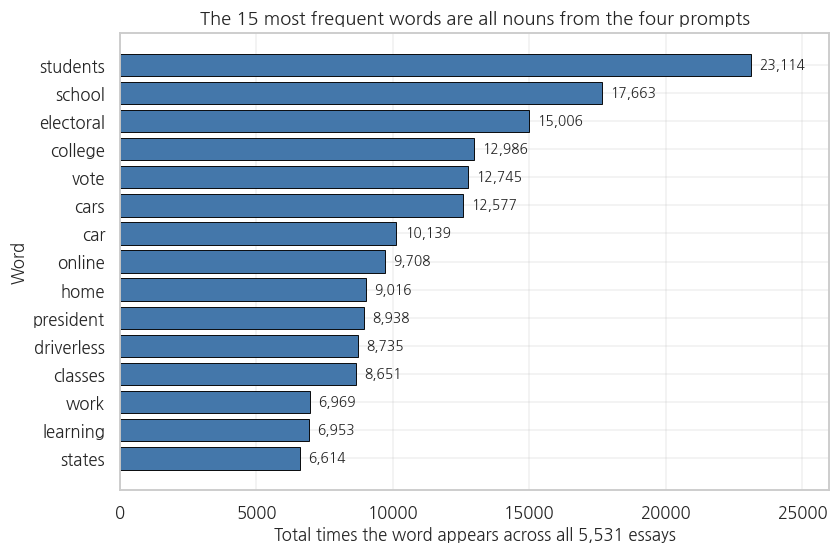

In [11]:
top15 = freq.head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(7.8, 5.2))
ax.barh(top15.index, top15.values, color=BLUE, edgecolor='black', linewidth=0.6)
ax.set_xlabel('Total times the word appears across all 5,531 essays')
ax.set_ylabel('Word')
ax.set_title('The 15 most frequent words are all nouns from the four prompts')
ax.set_xlim(0, 26000)
for y, v in enumerate(top15.values):
    ax.text(v + 300, y, f'{v:,}', va='center', fontsize=9)
plt.show()

**Let's look at the output.** Every word on this list is a noun from one of the four prompts: `students`, `school`, `electoral`, `college`, `vote`, `cars`, `car`, `online`, `home`, `president`. The frequency table has told us what the prompts were. It has told us nothing about what any student *argued*.

The more useful question is **which words are unusually common *here* compared to everywhere else.** That is what the next cell computes.

**Run the cell below.**

In [12]:
def distinctive_words(prompt, n=8, min_count=60):
    'Words whose share of one prompt most exceeds their share of the whole corpus.'
    rows = np.where((essays['prompt_short'] == prompt).values)[0]
    prompt_counts = np.asarray(X_counts[rows].sum(axis=0)).ravel()
    prompt_share = prompt_counts / prompt_counts.sum()
    overall_share = totals / totals.sum()
    ratio = np.where(prompt_counts >= min_count, prompt_share / overall_share, 0)
    return ', '.join(vocab[np.argsort(ratio)[::-1][:n]])

distinct = pd.DataFrame({
    'prompt': list(PROMPT_SHORT.values()),
    'distinctive words (appearing at least 60 times)':
        [distinctive_words(p) for p in PROMPT_SHORT.values()],
})
print(distinct.to_string(index=False))
print()
print('Where four of these words occur:')
cell_rows = essays['prompt_short'] == 'cell phones'
for w in ['principal', 'principle', 'alot', 'becuase']:
    n_all = int(totals[vocab == w][0]) if (vocab == w).any() else 0
    n_cell = int(essays.loc[cell_rows, 'clean']
                 .apply(lambda d, w=w: d.split().count(w)).sum())
    print(f'   {w:<12} {n_all:>6,} in the whole corpus, '
          f'{n_cell:>5,} of them inside the cell phone essays')

           prompt                                            distinctive words (appearing at least 60 times)
electoral college      senator, regional, invariably, republican, electors, democratic, governor, presidents
distance learning conferencing, illnesses, lectures, attended, enrolled, homeschooling, schooled, attendance
  driverless cars                    driverless, flashing, gm, tesla, manufactures, driveways, drunk, sensor
      cell phones                          policy, cell, principal, phones, principle, lunch, aloud, periods

Where four of these words occur:
   principal       591 in the whole corpus,   570 of them inside the cell phone essays
   principle       164 in the whole corpus,   152 of them inside the cell phone essays
   alot            422 in the whole corpus,     4 of them inside the cell phone essays
   becuase         215 in the whole corpus,     0 of them inside the cell phone essays


**Let's look at the output.** Try covering the first column with your hand and naming each prompt from its distinctive words alone. `conferencing, illnesses, lectures, enrolled, homeschooling` is distance learning. `flashing, gm, tesla, sensor` is driverless cars.

**The confidence available right now comes from the answer key.** In Section 5 a topic model hands you the same kind of list without the answer column.

Now the detail at the bottom. `principal` appears 591 times in the corpus and 570 of those are in the cell phone essays. `principle` appears 164 times, 152 of them in the same place. The `assignment` column for this prompt reads 'Write a letter to your principal'. 152 of the 164 uses of `principle` are in those essays. The vectorizer cannot tell which of the 152 are the intended `principal` and which are `principle` in its own sense, and `principle` enters the distinctive-words list either way.

A spellchecker could resolve that. Before reaching for one, it may be worth asking what else the spellchecker would change, whose writing it would change most, and whether the thing being measured afterward is still the thing the students wrote.

---

## 4. A stance lexicon

The lexicon is printed in full so it can be read and edited.

There is a second reason to change the instrument. "Sentiment" is a poor fit for argumentative writing. An essay arguing that driverless cars are dangerous will be full of `crash`, `accident`, and `danger` however good the argument is, and a sentiment score will register the topic and report it as the writer's mood. So we measure something closer to what actually varies in argument: **stance strength**.

- **Hedges** qualify a claim: `maybe`, `might`, `seems`, `probably`, `suggests`.
- **Boosters** assert a claim strongly: `always`, `clearly`, `obviously`, `proves`, `definitely`.

Both are features of academic argument. **Run the cell below** for the entire lexicon, fifty-two words. Every stance number in this section comes from these two lists and nothing else.

In [13]:
HEDGES = '''
maybe perhaps possibly probably might may could seems seem appears likely
somewhat arguably suggests suggest think believe sometimes often usually generally
tend tends unsure unclear roughly potentially
'''.split()

BOOSTERS = '''
always never definitely certainly obviously clearly absolutely must completely
totally undoubtedly proves prove proven fact facts truly everyone nobody impossible
essential crucial vital surely extremely
'''.split()

HEDGE_SET, BOOST_SET = set(HEDGES), set(BOOSTERS)

print(f'HEDGES   ({len(HEDGES)} words):')
print('  ', ', '.join(HEDGES))
print()
print(f'BOOSTERS ({len(BOOSTERS)} words):')
print('  ', ', '.join(BOOSTERS))
print()
print('The instrument is that list of words, and nothing else.')


HEDGES   (27 words):
   maybe, perhaps, possibly, probably, might, may, could, seems, seem, appears, likely, somewhat, arguably, suggests, suggest, think, believe, sometimes, often, usually, generally, tend, tends, unsure, unclear, roughly, potentially

BOOSTERS (25 words):
   always, never, definitely, certainly, obviously, clearly, absolutely, must, completely, totally, undoubtedly, proves, prove, proven, fact, facts, truly, everyone, nobody, impossible, essential, crucial, vital, surely, extremely

The instrument is that list of words, and nothing else.


Now the scorer. It is seven lines. We divide by essay length and multiply by 100, so the score is *hedges per hundred words*, not raw hedges. That matters a great deal here, since essays range from 146 to 6,188 words.

**Run the cell below.**

In [14]:
def stance_rates(text):
    'Return hedges per 100 words and boosters per 100 words.'
    tokens = re.sub(r"[^a-z\s']", ' ', text.lower()).split()
    n = max(len(tokens), 1)
    hedge = sum(1 for t in tokens if t in HEDGE_SET)
    boost = sum(1 for t in tokens if t in BOOST_SET)
    return 100 * hedge / n, 100 * boost / n

rates = essays['full_text'].apply(
    lambda t: pd.Series(stance_rates(t), index=['hedge_rate', 'booster_rate']))
essays[['hedge_rate', 'booster_rate']] = rates

print('Stance rates, per 100 words:')
print(essays[['hedge_rate', 'booster_rate']].describe().round(3).to_string())
print()
print(f'Essays with no word from the hedge list  : {(essays["hedge_rate"] == 0).sum():,} '
      f'({(essays["hedge_rate"] == 0).mean():.1%})')
print(f'Essays with no word from the booster list: {(essays["booster_rate"] == 0).sum():,} '
      f'({(essays["booster_rate"] == 0).mean():.1%})')
print(f'Essays with no word from either list      : '
      f'{((essays["hedge_rate"] == 0) & (essays["booster_rate"] == 0)).sum():,} '
      f'({((essays["hedge_rate"] == 0) & (essays["booster_rate"] == 0)).mean():.1%})')
print()
print('Mean rates by the score a human gave the essay:')
by_score = essays.groupby('holistic_essay_score').agg(
    essays=('essay_id', 'size'),
    hedge_rate=('hedge_rate', 'mean'),
    booster_rate=('booster_rate', 'mean'),
    mean_words=('essay_word_count', 'mean'),
).round(3)
print(by_score.to_string())

Stance rates, per 100 words:
       hedge_rate  booster_rate
count    5531.000      5531.000
mean        1.328         0.361
std         0.963         0.393
min         0.000         0.000
25%         0.636         0.000
50%         1.136         0.277
75%         1.810         0.555
max        13.983         2.865

Essays with no word from the hedge list  : 245 (4.4%)
Essays with no word from the booster list: 1,878 (34.0%)
Essays with no word from either list      : 122 (2.2%)

Mean rates by the score a human gave the essay:
                      essays  hedge_rate  booster_rate  mean_words
holistic_essay_score                                              
1                        200       1.026         0.223     362.575
2                       1012       1.491         0.308     285.876
3                       1811       1.410         0.344     368.530
4                       1428       1.293         0.383     481.801
5                        799       1.173         0.440     644.45

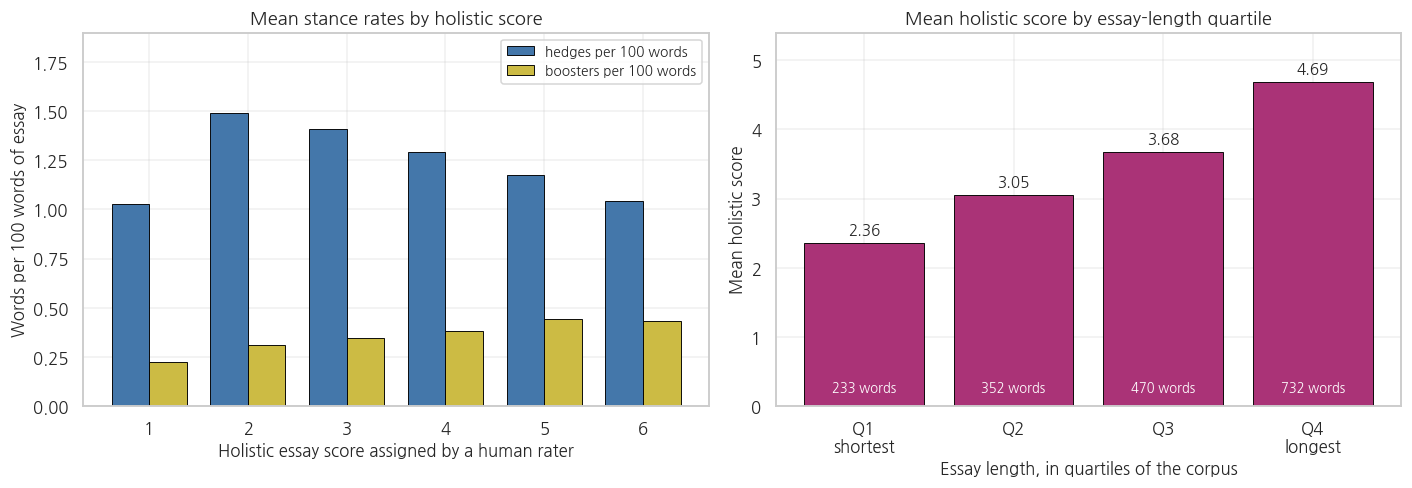

Essay length quartiles, which is what the right panel plots:
                n  mean_words  mean_score
wc_quartile                              
Q1 shortest  1384      233.48        2.36
Q2           1385      352.43        3.05
Q3           1381      469.50        3.68
Q4 longest   1381      731.62        4.69

Correlation with the human holistic score, computed two ways.
Two, because essay length is heavily right-skewed (146 to 6,188 words, median 406)
and the score is six ordered categories, not a continuous quantity. Pearson asks
whether a straight line fits the raw numbers. Spearman only asks whether the two
rankings move together, so a handful of very long essays cannot dominate it.

                                Pearson r  Spearman rho
   hedges per 100 words            -0.091        -0.067
   boosters per 100 words          +0.125        +0.187
   raw word count                  +0.559        +0.753


In [15]:
# Two panels: what the lexicon sees, and what a word count sees.
essays['wc_quartile'] = pd.qcut(essays['essay_word_count'], 4,
                                labels=['Q1\nshortest', 'Q2', 'Q3', 'Q4\nlongest'])
wc = essays.groupby('wc_quartile', observed=True).agg(
    n=('essay_id', 'size'),
    mean_words=('essay_word_count', 'mean'),
    mean_score=('holistic_essay_score', 'mean'),
).round(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

xs = by_score.index.values
w = 0.38
axes[0].bar(xs - w / 2, by_score['hedge_rate'], width=w, color=BLUE,
            edgecolor='black', linewidth=0.6, label='hedges per 100 words')
axes[0].bar(xs + w / 2, by_score['booster_rate'], width=w, color=YELLOW,
            edgecolor='black', linewidth=0.6, label='boosters per 100 words')
axes[0].set_xlabel('Holistic essay score assigned by a human rater')
axes[0].set_ylabel('Words per 100 words of essay')
axes[0].set_title('Mean stance rates by holistic score')
axes[0].set_xticks(list(xs))
axes[0].set_ylim(0, 1.9)
axes[0].legend(fontsize=9)

axes[1].bar(range(len(wc)), wc['mean_score'], color=PURPLE,
            edgecolor='black', linewidth=0.6)
axes[1].set_xticks(range(len(wc)))
axes[1].set_xticklabels(wc.index)
axes[1].set_xlabel('Essay length, in quartiles of the corpus')
axes[1].set_ylabel('Mean holistic score')
axes[1].set_title('Mean holistic score by essay-length quartile')
axes[1].set_ylim(0, 5.4)
for i, (v, mw) in enumerate(zip(wc['mean_score'], wc['mean_words'])):
    axes[1].text(i, v + 0.12, f'{v:.2f}', ha='center', fontsize=10)
    axes[1].text(i, 0.2, f'{mw:.0f} words', ha='center', fontsize=8.5, color='white')

plt.show()

print('Essay length quartiles, which is what the right panel plots:')
print(wc.rename(index=lambda s: str(s).replace(chr(10), ' ')).to_string())
print()
print('Correlation with the human holistic score, computed two ways.')
print('Two, because essay length is heavily right-skewed (146 to 6,188 words, median 406)')
print('and the score is six ordered categories, not a continuous quantity. Pearson asks')
print('whether a straight line fits the raw numbers. Spearman only asks whether the two')
print('rankings move together, so a handful of very long essays cannot dominate it.')
print()
print(f'   {"":<26}{"Pearson r":>12}{"Spearman rho":>14}')
for col, label in [('hedge_rate', 'hedges per 100 words'),
                   ('booster_rate', 'boosters per 100 words'),
                   ('essay_word_count', 'raw word count')]:
    r = essays[col].corr(essays['holistic_essay_score'])
    rho = essays[col].corr(essays['holistic_essay_score'], method='spearman')
    print(f'   {label:<26}{r:>+12.3f}{rho:>+14.3f}')

**Let's look at the output.**

The lexicon, fifty-two hedges and boosters small enough to read in full, correlates with the human score at **r = -0.091** for hedges and **r = +0.125** for boosters. In the left panel, hedging peaks in the essays scored 2 (1.49 per 100 words) and falls to 1.05 at score 6, except that the essays scored 1 are the least hedged of all at 1.03. So the relationship is not even monotonic, and the whole range is under half a word per hundred.

The right panel is raw word count, which required no lexicon, no theory, and no judgment. It correlates with the human score at **r = +0.559**, and at **rho = +0.753** once ranks are compared instead of raw values. Both are in the printout, and the second is the one to quote: essay length runs from 146 to 6,188 words, so a few very long essays can distort a Pearson correlation, while a rank correlation cannot be moved by them. The rank association is stronger than the linear association on the raw scale, not weaker. (The two stance measures barely move under either: -0.091 and -0.067 for hedges, +0.125 and +0.187 for boosters.)

The shortest quarter of essays (mean 233 words) averages a score of **2.36**. The longest quarter (mean 732 words) averages **4.69**. That is a gap of more than two points on a six-point scale, from a word count alone.

**Let's discuss.** One pattern worth noticing is how strongly the human score is associated with length alone. What are some plausible explanations, and what additional information would help distinguish among them? Three explanations:

1. **Longer essays are more developed essays.** Developing an argument takes words, so length is a crude proxy for elaboration.
2. **Raters respond to length.** Under time pressure a full page reads as effort, and rubrics that mention "development" invite that reading.
3. **Length stands in for something else**, such as typing speed, a testing accommodation, or how much of the class period the student had left.

| | |
|---|---|
| **What the data directly show** | Word count correlates with the holistic score at r = +0.559 and rho = +0.753; the two stance rates correlate at -0.091 and +0.125. The longest quartile (mean 732 words) averages 4.69 and the shortest (mean 233 words) averages 2.36. |
| **A plausible interpretation** | Any of the three explanations above, or a mixture of them. |
| **What this file cannot establish** | Which of them is operating. The corpus records no rater identifiers, no testing conditions, and no time on task. |

What can be said either way is that any automated scorer trained on these labels has the length relationship available to it, and of the features computed here it is the strongest association. Section 6 returns to this.

And one more thing in the printout: **122 essays contain no word from either list.** For those essays the instrument returns 0.0 for both, which will be read downstream as "perfectly neutral stance." The instrument did not measure those essays at all, and a mean cannot tell that apart from a neutral score.

*Connecting to the readings.* Allen, Creer and Öncel (2022) argue for a multi-dimensional view of language as evidence about learning, on the grounds that no single index of a text captures what a learner is doing. This section puts two indices side by side and finds that the theoretically motivated one moves least. Whether that is the multi-dimensionality they describe, or a warning that the dimensions easiest to measure are not the ones that matter, is a question worth taking a position on in the memo.

### Your turn 2: edit the lexicon

Below, `WORDS_TO_DROP` removes hedge words that are arguably not hedges at all. `think` and `believe` are the borderline case: "I think phones should be banned" is a first-person assertion, not a qualification, and `I think` can be a sentence starter rather than an epistemic marker.

The list ships with a working default, so run it untouched first. Then change it, re-run, and compare the two correlations.

In [16]:
# TODO (optional): edit this list. Which of these are real hedges, and which
# are just how a fourteen-year-old starts a sentence?
WORDS_TO_DROP = ['think', 'believe', 'often', 'sometimes', 'usually', 'generally']

HEDGE_SET_V2 = HEDGE_SET - set(WORDS_TO_DROP)
print(f'Hedge lexicon: {len(HEDGE_SET)} words -> {len(HEDGE_SET_V2)} words')
print(f'Dropped: {", ".join(sorted(set(WORDS_TO_DROP) & HEDGE_SET))}')
print()

def hedge_v2(text):
    tokens = re.sub(r"[^a-z\s']", ' ', text.lower()).split()
    return 100 * sum(1 for t in tokens if t in HEDGE_SET_V2) / max(len(tokens), 1)

essays['hedge_rate_v2'] = essays['full_text'].apply(hedge_v2)

compare = essays.groupby('holistic_essay_score')[['hedge_rate', 'hedge_rate_v2']].mean().round(3)
compare['change'] = (compare['hedge_rate_v2'] - compare['hedge_rate']).round(3)
print('Mean hedge rate by human score, version 1 against version 2:')
print(compare.to_string())
print()
def both_correlations(col):
    return (essays[col].corr(essays['holistic_essay_score']),
            essays[col].corr(essays['holistic_essay_score'], method='spearman'))

print(f'{"Correlation with the human score":<38}{"Pearson r":>12}{"Spearman rho":>14}')
for col, label in [('hedge_rate', '  hedge lexicon, v1'),
                   ('hedge_rate_v2', '  hedge lexicon, v2'),
                   ('essay_word_count', '  raw word count, for comparison')]:
    r, rho = both_correlations(col)
    print(f'{label:<38}{r:>+12.3f}{rho:>+14.3f}')

Hedge lexicon: 27 words -> 21 words
Dropped: believe, generally, often, sometimes, think, usually



Mean hedge rate by human score, version 1 against version 2:
                      hedge_rate  hedge_rate_v2  change
holistic_essay_score                                   
1                          1.026          0.461  -0.565
2                          1.491          0.741  -0.750
3                          1.410          0.810  -0.600
4                          1.293          0.866  -0.427
5                          1.173          0.867  -0.306
6                          1.045          0.818  -0.227

Correlation with the human score         Pearson r  Spearman rho


  hedge lexicon, v1                         -0.091        -0.067
  hedge lexicon, v2                         +0.077        +0.141
  raw word count, for comparison            +0.559        +0.753


**Let's look at the output, and at the sign in particular.**

Version 1 correlates with the human score at **r = -0.091**. Version 2, after deleting six words, correlates at **r = +0.077**. The relationship changed direction. It is not an artifact of which correlation is used: the rank version flips too, from **rho = -0.067** to **rho = +0.141**.

Neither correlation is strong enough to build anything on. A published version 1 would have said that stronger essays hedge less. A published version 2 would have said that stronger essays hedge more. The corpus, the construct, and the reasoning were the same in both versions, and six words separated them.

A reader who can see the lexicon can check it. A reader handed "hedging was negatively associated with essay quality" cannot.

Meanwhile the raw word count is unchanged at **r = +0.559**. Section 4 has now shown both failure modes of lexicon work in one place: a measure that is easy to change and does not move much, alongside a measure with no theoretical motivation and a strong association.

A sentence about this belongs in your memo. Which of the two would you report to a teacher, which would you hold back, and why is that not the same question as which one is more accurate?

---

## 5. Topic modeling: NMF and LDA, side by side

A topic model reads a pile of documents and proposes groups of words that tend to occur together. It does not name the groups and it has no access to the prompts.

We fit two of them on the same 5,531 essays:

- **NMF** (Non-negative Matrix Factorization) is linear algebra. It factors the document-term matrix into two non-negative matrices and reads topics off one of them. It usually pairs with **TF-IDF** weighting, which downweights words that appear everywhere.
- **LDA** (Latent Dirichlet Allocation) is a probability model. It supposes every document is a mixture of topics and every topic is a distribution over words, then estimates both. It uses raw counts.

We have something rare here: **an answer key.** These essays answer four known prompts. So we can ask for four topics and check the models against the truth, which is rare.

In [17]:
N_TOPICS = 4

# NMF wants TF-IDF weighting.
tfidf_vec = TfidfVectorizer(stop_words=MY_STOPWORDS, min_df=5, max_df=0.5)
X_tfidf = tfidf_vec.fit_transform(essays['clean'])
tfidf_vocab = np.array(tfidf_vec.get_feature_names_out())

nmf_model = NMF(n_components=N_TOPICS, random_state=RANDOM_STATE,
                init='nndsvda', max_iter=400)
W_nmf = nmf_model.fit_transform(X_tfidf)

# LDA wants raw counts, which we already built in Section 3.
lda_model = LatentDirichletAllocation(n_components=N_TOPICS, random_state=RANDOM_STATE,
                                      max_iter=20, learning_method='batch')
W_lda = lda_model.fit_transform(X_counts)

def top_words(model, feature_names, n=10):
    return [', '.join(feature_names[c.argsort()[-n:][::-1]]) for c in model.components_]

nmf_words = top_words(nmf_model, tfidf_vocab)
lda_words = top_words(lda_model, vocab)

side_by_side = pd.DataFrame({
    'k': range(N_TOPICS),
    'NMF topic (top 10 words)': nmf_words,
    'LDA topic (top 10 words)': lda_words,
})
print('Two models, four topics each, same corpus:')
print(side_by_side.to_string(index=False))

Two models, four topics each, same corpus:
 k                                                               NMF topic (top 10 words)                                                               LDA topic (top 10 words)
 0 electoral, vote, college, president, electors, votes, states, popular, election, state electoral, vote, college, president, states, electors, votes, popular, state, election
 1      students, school, online, classes, home, learning, work, student, distance, learn         students, school, online, classes, home, learning, work, student, class, learn
 2        cars, car, driverless, driver, driving, drive, technology, road, human, drivers               phones, school, cell, students, phone, use, class, policy, student, free
 3                 phones, cell, school, phone, policy, students, use, class, lunch, free           cars, car, driverless, driver, driving, drive, technology, make, human, road


**Let's look at the output.** Try covering the rest of the notebook and naming all eight topics from the words alone. Both models found the same four topics.

One thing worth noticing about what just happened: those topics were not named from the word lists. They were recognized, because the prompt table in Section 1 has already been read and the four answers were already known. That is recall. The next cell checks whether the recognition was right.

**Run the cell below.**

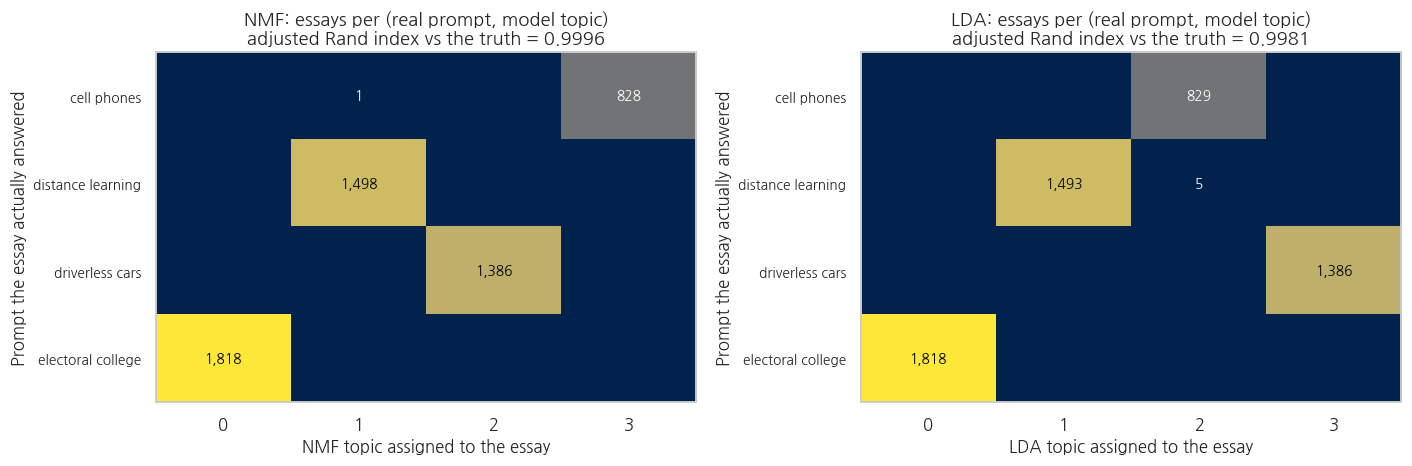

Essays NMF filed under a topic that is not its prompt's main topic : 1 of 5,531
Essays LDA filed under a topic that is not its prompt's main topic : 5 of 5,531
Adjusted Rand index against the real prompts, NMF                 : 0.9996
Adjusted Rand index against the real prompts, LDA                 : 0.9981
Agreement between the two models (adjusted Rand index)             : 0.9977


In [18]:
essays['nmf_topic'] = W_nmf.argmax(axis=1)
essays['lda_topic'] = W_lda.argmax(axis=1)

ct_nmf = pd.crosstab(essays['prompt_short'], essays['nmf_topic'])
ct_lda = pd.crosstab(essays['prompt_short'], essays['lda_topic'])

ari_nmf = adjusted_rand_score(essays['prompt_short'], essays['nmf_topic'])
ari_lda = adjusted_rand_score(essays['prompt_short'], essays['lda_topic'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for ax, ct, name in zip(axes, [ct_nmf, ct_lda], ['NMF', 'LDA']):
    ax.imshow(ct.values, cmap='cividis', aspect='auto')
    ax.set_xticks(range(ct.shape[1]))
    ax.set_xticklabels(ct.columns)
    ax.set_yticks(range(ct.shape[0]))
    ax.set_yticklabels(ct.index, fontsize=9)
    ax.set_xlabel(f'{name} topic assigned to the essay')
    ax.set_ylabel('Prompt the essay actually answered')
    ari = ari_nmf if name == 'NMF' else ari_lda
    ax.set_title(f'{name}: essays per (real prompt, model topic)\n'
                 f'adjusted Rand index vs the truth = {ari:.4f}')
    ax.grid(False)
    for i in range(ct.shape[0]):
        for j in range(ct.shape[1]):
            v = ct.values[i, j]
            if v > 0:
                ax.text(j, i, f'{v:,}', ha='center', va='center', fontsize=9,
                        color='white' if v < ct.values.max() * 0.5 else 'black')
plt.show()

off_nmf = int(ct_nmf.values.sum() - ct_nmf.values.max(axis=1).sum())
off_lda = int(ct_lda.values.sum() - ct_lda.values.max(axis=1).sum())
print(f'Essays NMF filed under a topic that is not its prompt\'s main topic : {off_nmf} of {len(essays):,}')
print(f'Essays LDA filed under a topic that is not its prompt\'s main topic : {off_lda} of {len(essays):,}')
print(f'Adjusted Rand index against the real prompts, NMF                 : {ari_nmf:.4f}')
print(f'Adjusted Rand index against the real prompts, LDA                 : {ari_lda:.4f}')
print(f'Agreement between the two models (adjusted Rand index)             : '
      f'{adjusted_rand_score(essays["nmf_topic"], essays["lda_topic"]):.4f}')

**Let's look at the two heatmaps, and then let's discuss.**

Both models recovered the prompts. NMF misplaces **1 essay out of 5,531** (adjusted Rand index 0.9996). LDA misplaces **5** (0.9981). The two models agree with each other at 0.9977. 

There are reasons to hold that conclusion loosely. This is close to the easiest possible version of the task:

- We **knew there were four groups**, so we asked for four. In real corpus work there is no answer key for the number of topics.
- The four groups are about **completely unrelated subjects**. Cars, phones, voting, and online school share almost no vocabulary. Any method that counts words would separate them, including sorting essays by whether they contain the word "car."
- The thing the model recovered, **which prompt an essay answers, is already a column in the file.** Nothing was learned that was not already held.

**A topic model that reproduces a variable already in hand has demonstrated that it works.** Whether it is useful turns on what happens when it is asked for structure the file does not already record. That is the next cell.

### Your turn 3: ask for more topics than there are prompts

Nothing in the data told us to use four topics. We assumed it. Change `N_TOPICS_TRY` below and see what the model does when you ask it for a number the answer key cannot confirm. It runs with 8 as written, which splits each prompt roughly in half.

As it runs, notice that the model will always give you exactly the number of topics you ask for and will never tell you the number was wrong. Then compare the composition table underneath with the word lists.

In [19]:
# TODO (optional): try 8, then 3, then 12. What happens to the word lists?
N_TOPICS_TRY = 8

trial = NMF(n_components=N_TOPICS_TRY, random_state=RANDOM_STATE,
            init='nndsvda', max_iter=400).fit(X_tfidf)
trial_assign = trial.transform(X_tfidf).argmax(axis=1)

print(f'NMF with {N_TOPICS_TRY} topics:\n')
for i, words in enumerate(top_words(trial, tfidf_vocab, n=9)):
    print(f'  topic {i}: {words}')
print()
print('Prompts folded into each topic (count of essays):')
print(pd.crosstab(essays['prompt_short'], trial_assign).to_string())
print()
print(f'Adjusted Rand index against the real prompts: '
      f'{adjusted_rand_score(essays["prompt_short"], trial_assign):.3f} '
      f'(it was {ari_nmf:.4f} at four topics)')
print()

# Zoom in on one prompt, and look at who ends up in each sub-topic.
essays['trial_topic'] = trial_assign
zoom = essays[(essays['prompt_short'] == 'distance learning') &
              (essays['ell_status'].isin(['Yes', 'No']))]
profile = zoom.groupby('trial_topic').agg(
    essays=('essay_id', 'size'),
    mean_score=('holistic_essay_score', 'mean'),
    mean_words=('essay_word_count', 'mean'),
    pct_ELL=('ell_status', lambda s: 100 * (s == 'Yes').mean()),
).round({'mean_score': 2, 'mean_words': 1, 'pct_ELL': 1})
profile = profile[profile['essays'] >= 30].sort_values('pct_ELL')
print('Inside the distance learning prompt alone, the essays in each sub-topic:')
print(profile.to_string())

NMF with 8 topics:

  topic 0: electoral, college, votes, states, president, election, popular, candidate, state
  topic 1: online, classes, students, class, home, attend, taking, benefit, work
  topic 2: cars, driverless, driver, technology, driving, human, drivers, future, accidents
  topic 3: phones, cell, policy, phone, use, students, class, lunch, free
  topic 4: students, learning, distance, home, learn, student, education, schools, classroom
  topic 5: vote, president, electors, voting, popular, state, electoral, voters, election
  topic 6: car, driver, drive, driving, driveless, road, self, driverless, accident
  topic 7: school, home, kids, work, student, parents, help, don, need

Prompts folded into each topic (count of essays):
col_0                0    1    2    3    4     5    6    7
prompt_short                                              
cell phones          0    0    0  773    5     0    0   51
distance learning    0  507    0    0  608     0    0  383
driverless cars

**Let's look at the output, and at that last table in particular.**

At eight topics NMF splits each prompt into sub-topics, and the adjusted Rand index against the prompts drops to 0.595 because there is no longer a one-to-one mapping. That is expected.

Now the distance learning prompt on its own. The model split those 1,498 essays into three groups using nothing but word counts, and the three groups have **almost identical average length** (604, 578, and 572 words, listed in the order of the bullets below) but very different composition:

- one sub-topic is **12.7 percent** English language learners and averages a score of **4.69**
- one is **27.9 percent** and averages **4.18**
- one is **37.5 percent** and averages **4.25**

Nobody gave the model an ELL column. It never saw a demographic variable. It was given words, and it sorted essays in a way that partly tracks the writers' ELL classification.

The word distributions differ across the classification, and words were all the model had. That is why "we did not use race or language status as a feature" is not on its own a defense of a text model. **A model trained on words has access to whatever the words carry about the writer.** Section 7 builds on that.

---

## 6. Human ground truth

Section 4 compared document features with one human score per essay. Nothing yet has checked a model against a human judgment made span by span, and this corpus carries one.

This corpus is different. **Human beings read every one of these essays and marked, span by span, what each piece of the argument was doing.** Then they rated how well it did it.

The scheme has seven moves:

| Move | What the annotator was marking |
|---|---|
| `Lead` | an opening written to interest the reader before the argument starts |
| `Position` | the writer's own stance on the question |
| `Claim` | a reason supporting the position |
| `Counterclaim` | a reason someone on the *other* side would give |
| `Rebuttal` | the writer's answer to a counterclaim |
| `Evidence` | facts, examples, or source material backing a claim |
| `Concluding Statement` | the close |

Plus `Unannotated`, which is text the annotators did not assign to any move.

And every marked span carries **Effective, Adequate, or Ineffective**.

This is what "ground truth" means here. It is **a record of what trained human raters decided**, made under a rubric, and it is not the truth about the writing. Crossley et al. (2024) report the agreement between annotators on these labels; the file carries one rating per span and no annotator identifier, so agreement cannot be checked here. Every model fit against it learns those decisions, including anything systematically wrong with them.

**Run the cell below.**

In [20]:
print('SPANS: the human annotation layer')
print(f'  total spans                 : {len(spans):,}')
print(f'  marked "Unannotated"        : {(spans["discourse_type"] == "Unannotated").sum():,} '
      f'({(spans["discourse_type"] == "Unannotated").mean():.1%} of spans)')
print(f'  missing an effectiveness rating : {spans["discourse_effectiveness"].isna().sum():,}')
print()
print('Which spans have no effectiveness rating?')
print(spans[spans['discourse_effectiveness'].isna()]['discourse_type']
      .value_counts().to_string())
print()
print('So: the unrated spans are the Unannotated ones, plus two others')
print('that slipped through. Two rows out of 63,211. They are dropped.')
print()

# The decision, stated: keep spans that have both a real type and a rating.
rated = spans[(spans['discourse_type'] != 'Unannotated') &
              (spans['discourse_effectiveness'].notna())].copy()
rated['n_words'] = rated['discourse_text'].str.split().str.len()
print(f'Working set for this section: {len(rated):,} spans '
      f'(dropped {len(spans) - len(rated):,}: {(spans["discourse_type"] == "Unannotated").sum():,} '
      f'Unannotated plus 2 unrated).')
print()
print('What that drop changes: the Unannotated spans are 12.9 percent of the span table,')
print('and they are the text the annotators did not assign to any move.')
print('Any claim we make below is a claim about the parts of these essays')
print('that a human recognized as argument.')
print()

profile = rated.groupby('discourse_type').agg(
    spans=('essay_id', 'size'),
    mean_words=('n_words', 'mean'),
    median_words=('n_words', 'median'),
).round(1).sort_values('spans', ascending=False)
print(profile.to_string())
print()
print('How the humans rated them, overall:')
print((rated['discourse_effectiveness'].value_counts(normalize=True) * 100).round(1).to_string())

SPANS: the human annotation layer
  total spans                 : 63,211
  marked "Unannotated"        : 8,141 (12.9% of spans)
  missing an effectiveness rating : 8,143

Which spans have no effectiveness rating?
discourse_type
Unannotated    8141
Position          1
Lead              1

So: the unrated spans are the Unannotated ones, plus two others
that slipped through. Two rows out of 63,211. They are dropped.

Working set for this section: 55,068 spans (dropped 8,143: 8,141 Unannotated plus 2 unrated).

What that drop changes: the Unannotated spans are 12.9 percent of the span table,
and they are the text the annotators did not assign to any move.
Any claim we make below is a claim about the parts of these essays
that a human recognized as argument.

                      spans  mean_words  median_words
discourse_type                                       
Claim                 19200        18.4          16.0
Evidence              16888        76.4          66.0
Position           

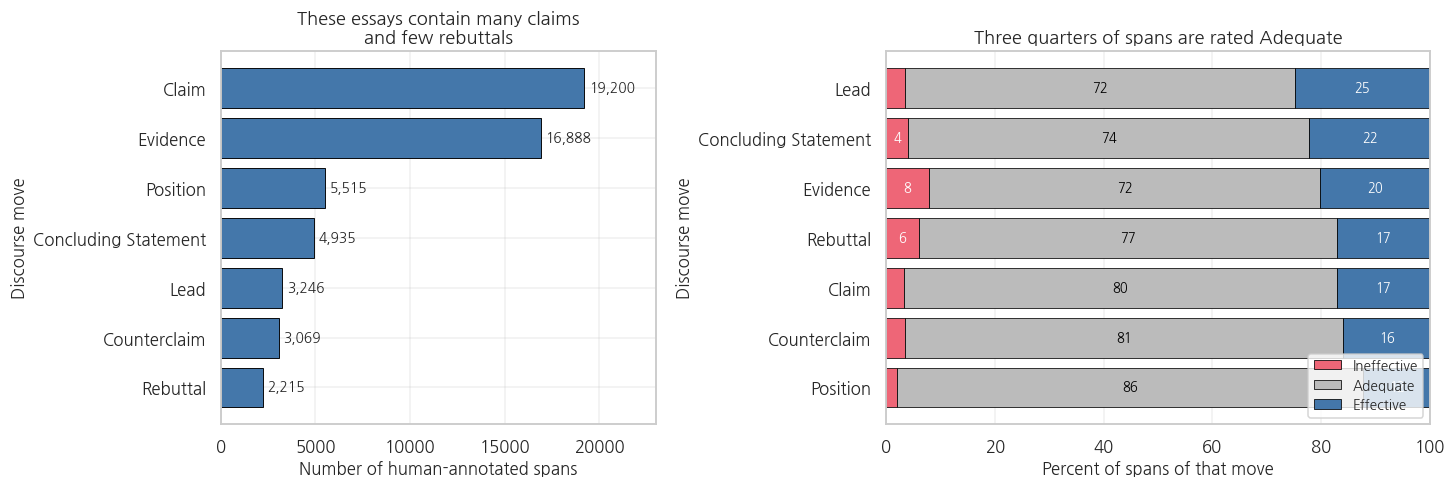

The right panel as a table, because the percentages matter to one decimal:
discourse_effectiveness  Ineffective  Adequate  Effective
discourse_type                                           
Position                         2.0      85.7       12.3
Counterclaim                     3.5      80.5       16.0
Claim                            3.3      79.5       17.2
Rebuttal                         6.0      76.7       17.2
Evidence                         8.0      71.7       20.3
Concluding Statement             4.1      73.6       22.2
Lead                             3.5      71.5       24.9

Claims per rebuttal in this corpus: 8.7 (19,200 claims, 2,215 rebuttals)


In [21]:
eff_by_type = pd.crosstab(rated['discourse_type'], rated['discourse_effectiveness'],
                          normalize='index')[['Ineffective', 'Adequate', 'Effective']] * 100
eff_by_type = eff_by_type.sort_values('Effective')
n_by_type = rated['discourse_type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.6), gridspec_kw={'width_ratios': [1, 1.25]})

order = n_by_type.sort_values().index
axes[0].barh(order, n_by_type[order].values, color=BLUE, edgecolor='black', linewidth=0.6)
for y, v in enumerate(n_by_type[order].values):
    axes[0].text(v + 250, y, f'{v:,}', va='center', fontsize=9)
axes[0].set_xlabel('Number of human-annotated spans')
axes[0].set_ylabel('Discourse move')
axes[0].set_title('These essays contain many claims\nand few rebuttals')
axes[0].set_xlim(0, 23000)

left = np.zeros(len(eff_by_type))
for col, colr in [('Ineffective', ROSE), ('Adequate', GREY), ('Effective', BLUE)]:
    axes[1].barh(eff_by_type.index, eff_by_type[col], left=left, color=colr,
                 edgecolor='black', linewidth=0.5, label=col)
    for y, (v, l) in enumerate(zip(eff_by_type[col], left)):
        if v > 4:
            axes[1].text(l + v / 2, y, f'{v:.0f}', ha='center', va='center',
                         fontsize=8.5, color='white' if col != 'Adequate' else 'black')
    left = left + eff_by_type[col].values
axes[1].set_xlabel('Percent of spans of that move')
axes[1].set_ylabel('Discourse move')
axes[1].set_title('Three quarters of spans are rated Adequate')
axes[1].set_xlim(0, 100)
axes[1].legend(fontsize=9, loc='lower right')
plt.show()

print('The right panel as a table, because the percentages matter to one decimal:')
print(eff_by_type.round(1).to_string())
print()
print(f'Claims per rebuttal in this corpus: '
      f'{n_by_type["Claim"] / n_by_type["Rebuttal"]:.1f} '
      f'({n_by_type["Claim"]:,} claims, {n_by_type["Rebuttal"]:,} rebuttals)')

**Let's look at the output.**

**The moves are unequal in number.** 19,200 claims against 2,215 rebuttals, which is **8.7 claims for every rebuttal** in this corpus. Before reading that as a fact about young writers, it is worth noticing the task. These are assessment essays answering prompts that asked for a position and reasons. A rebuttal takes two moves, stating the objection and answering it, and only the electoral college prompt instructs writers to 'address counterclaims'. The ratio is a property of the genre and the prompts at least as much as of the people who did the writing.

**Most ratings are Adequate.** 76.7 percent of all spans are Adequate, 18.5 percent Effective, 4.8 percent Ineffective. A scale where three quarters of the mass sits in the middle category has less resolution than its three categories suggest, as with the holistic score in Section 1. This is the second time that shape has appeared.

**`Evidence` is the move raters mark down most often.** Its Ineffective rate is 8.0 percent, four times Position's 2.0. Its Effective rate, 20.3 percent, is third, behind `Lead` at 24.9 and `Concluding Statement` at 22.2. Position, by contrast, draws the middle category more than any other move: 85.7 percent of Position spans are called Adequate.

Before reading that column as a ranking of moves, it is worth putting it beside the length column in the table above. The three moves with the highest Effective rates, `Lead`, `Concluding Statement`, and `Evidence`, are also the three longest, at 52, 61, and 76 words against 18 for a `Claim`. The effectiveness model later in this section puts a number on that.

Please write one sentence for your memo: if you built a feedback tool from this table alone, what would it tell a student to do more of, and would that advice be good?

### Now build a classifier, and check it against the humans

This step uses the annotation layer. We are going to train a model to predict **what kind of argumentative move a span is**, using nothing but the words in that span, and then check its answers against what a human annotator decided.

It is checked against 13,767 human judgments the model has never seen, not against our own intuition.

The model is deliberately plain: **a bag of words fed to multinomial naive Bayes.** Count how often each word appears in each class, apply Bayes' rule, predict the most probable class. There is no deep learning here, no embedding, no context.

One note on the split, and a check. We split spans at random, which means spans from the *same essay* land on both sides. With about eleven spans per essay that is not an edge case, it happens to essentially every essay in the test set: the model could learn one student's phrasing in training and meet it again in testing. The stricter design splits by **essay**, so no essay appears on both sides.

The next cell fits the same model both ways and prints both numbers, so both numbers are in view.

In [22]:
train, test = train_test_split(rated, test_size=0.25, random_state=RANDOM_STATE,
                               stratify=rated['discourse_type'])

# Note: the RAW span text, not the cleaned column. Section 2 explained why.
span_vec = CountVectorizer(min_df=3, max_features=20000)
X_train = span_vec.fit_transform(train['discourse_text'])
X_test = span_vec.transform(test['discourse_text'])

clf = MultinomialNB(alpha=0.3)
clf.fit(X_train, train['discourse_type'])
pred = clf.predict(X_test)

majority = train['discourse_type'].value_counts().idxmax()
baseline = (test['discourse_type'] == majority).mean()

print(f'Training spans : {len(train):,}')
print(f'Testing spans  : {len(test):,}')
print(f'Vocabulary     : {X_train.shape[1]:,} words')
print()
print(f'Accuracy                              : '
      f'{accuracy_score(test["discourse_type"], pred):.4f}')
print(f'Always guessing "{majority}" would give : {baseline:.4f}')
print(f'Macro F1 (treats every move as equally important) : '
      f'{f1_score(test["discourse_type"], pred, average="macro"):.4f}')
print()
print('Per-move report. Read the recall column, not the accuracy:')
print(classification_report(test['discourse_type'], pred, digits=3, zero_division=0))

# --- the check promised above: is the random span split flattering the model? ---
# GroupShuffleSplit keeps every span from one essay on the same side of the line.
strict_i, strict_j = next(GroupShuffleSplit(n_splits=1, test_size=0.25,
                                            random_state=RANDOM_STATE)
                          .split(rated, groups=rated['essay_id']))
strict_train, strict_test = rated.iloc[strict_i], rated.iloc[strict_j]
strict_vec = CountVectorizer(min_df=3, max_features=20000)
S_train = strict_vec.fit_transform(strict_train['discourse_text'])
S_test = strict_vec.transform(strict_test['discourse_text'])
strict_pred = (MultinomialNB(alpha=0.3)
               .fit(S_train, strict_train['discourse_type'])
               .predict(S_test))

print('THE SAME MODEL, SPLIT BY ESSAY')
print(f'  test spans whose essay also supplied training spans, random span split : '
      f'{test["essay_id"].isin(set(train["essay_id"])).mean():.1%}')
print(f'  the same, once the split is made by essay                             : '
      f'{strict_test["essay_id"].isin(set(strict_train["essay_id"])).mean():.1%}')
print(f'  accuracy, random span split : '
      f'{accuracy_score(test["discourse_type"], pred):.4f}')
print(f'  accuracy, split by essay    : '
      f'{accuracy_score(strict_test["discourse_type"], strict_pred):.4f}')
print('  The two accuracies come from different test sets and no test is run.')
print('  Read them as two descriptive numbers.')

Training spans : 41,301
Testing spans  : 13,767
Vocabulary     : 8,692 words

Accuracy                              : 0.5472
Always guessing "Claim" would give : 0.3487
Macro F1 (treats every move as equally important) : 0.4609

Per-move report. Read the recall column, not the accuracy:
                      precision    recall  f1-score   support

               Claim      0.619     0.563     0.590      4800
Concluding Statement      0.397     0.498     0.442      1234
        Counterclaim      0.332     0.343     0.337       767
            Evidence      0.610     0.611     0.610      4222
                Lead      0.403     0.476     0.436       811
            Position      0.569     0.656     0.609      1379
            Rebuttal      0.294     0.153     0.202       554

            accuracy                          0.547     13767
           macro avg      0.461     0.471     0.461     13767
        weighted avg      0.550     0.547     0.546     13767



THE SAME MODEL, SPLIT BY ESSAY
  test spans whose essay also supplied training spans, random span split : 99.9%
  the same, once the split is made by essay                             : 0.0%
  accuracy, random span split : 0.5472
  accuracy, split by essay    : 0.5644
  The two accuracies come from different test sets and no test is run.
  Read them as two descriptive numbers.


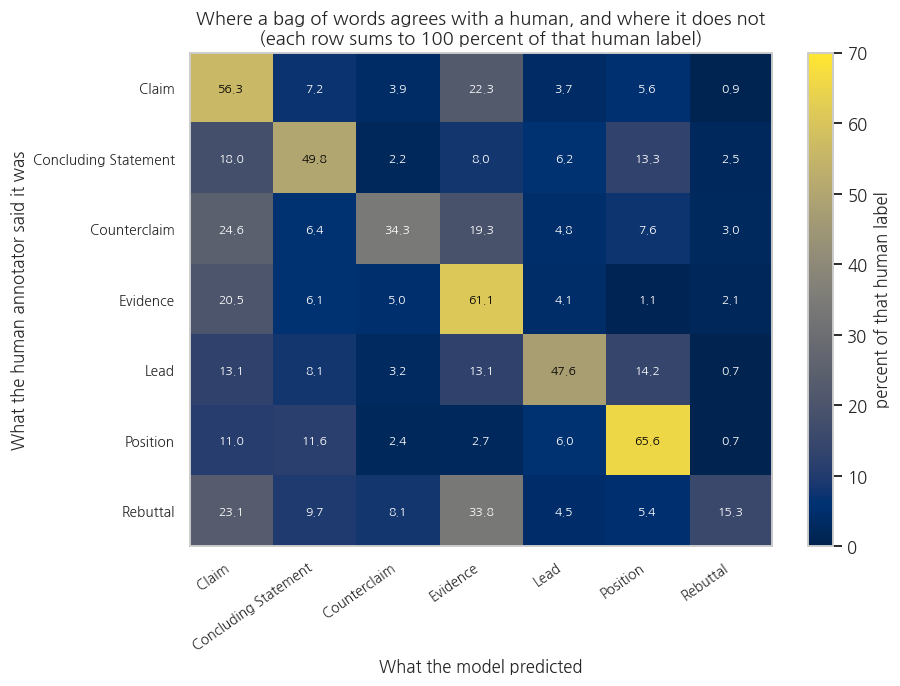

In [23]:
cm = pd.crosstab(test['discourse_type'], pred, normalize='index') * 100
labels = list(cm.index)
cm = cm.reindex(columns=labels, fill_value=0)

fig, ax = plt.subplots(figsize=(8.6, 6.4))
im = ax.imshow(cm.values, cmap='cividis', aspect='auto', vmin=0, vmax=70)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=9)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('What the model predicted')
ax.set_ylabel('What the human annotator said it was')
ax.set_title('Where a bag of words agrees with a human, and where it does not\n'
             '(each row sums to 100 percent of that human label)')
ax.grid(False)
for i in range(len(labels)):
    for j in range(len(labels)):
        v = cm.values[i, j]
        ax.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=8,
                color='white' if v < 35 else 'black')
fig.colorbar(im, ax=ax, label='percent of that human label')
plt.show()

**Let's look at the output.**

Overall accuracy is **54.7 percent** against a majority-class baseline of **34.9 percent**, so the model learned something real. Now the rows.

- **Position: 65.6 percent correct.** That is the easiest move. Position spans share a small vocabulary (`I think`, `I believe`, `in my opinion`), and a word counter finds it.
- **Evidence: 61.1 percent correct.** This one is also easy: Evidence spans average 76 words against 18 for a Claim. The model may be partly detecting *length*.
- **Counterclaim: 34.3 percent correct.** Almost a quarter of real counterclaims get called Claims.
- **Rebuttal: 15.3 percent correct.** The model gets it right roughly one time in seven. **33.8 percent of real rebuttals are labeled Evidence** and 23.1 percent are labeled Claim.

The next cell puts some of those spans on the screen so we can consider why.

**Run the cell below.**

In [24]:
test = test.copy()
test['pred'] = pred

print('=== REAL REBUTTALS THAT THE MODEL CALLED EVIDENCE ===')
print(f'({int(((test["discourse_type"] == "Rebuttal") & (test["pred"] == "Evidence")).sum())} '
      f'of the {int((test["discourse_type"] == "Rebuttal").sum())} rebuttals in the test set)\n')
missed = test[(test['discourse_type'] == 'Rebuttal') & (test['pred'] == 'Evidence')]
for _, r in missed.sample(3, random_state=1).iterrows():
    print(f'  [human said: Rebuttal, {r["discourse_effectiveness"]} | model said: Evidence]')
    print('   ', r['discourse_text'].strip()[:330])
    print()

print('=== REBUTTALS THE MODEL GOT RIGHT, FOR CONTRAST ===\n')
hit = test[(test['discourse_type'] == 'Rebuttal') & (test['pred'] == 'Rebuttal')]
for _, r in hit.sample(2, random_state=1).iterrows():
    print('   ', r['discourse_text'].strip()[:240])
    print()

print('=== REAL COUNTERCLAIMS THAT THE MODEL CALLED CLAIMS ===\n')
cc = test[(test['discourse_type'] == 'Counterclaim') & (test['pred'] == 'Claim')]
for _, r in cc.sample(2, random_state=1).iterrows():
    print('   ', r['discourse_text'].strip()[:280])
    print()

=== REAL REBUTTALS THAT THE MODEL CALLED EVIDENCE ===
(187 of the 554 rebuttals in the test set)

  [human said: Rebuttal, Effective | model said: Evidence]
    but according to history things can happen such as in the 2000 election. Why keep a process that the majority of the citizens of this country don't want and a process that just causes issues.

  [human said: Rebuttal, Ineffective | model said: Evidence]
    with that being said with the presidents trying to run for president the will actually try to reach the peoples needs to meet there satisfactory. the swing states is sayiong that there one state isnt going to decide the whole election.

  [human said: Rebuttal, Effective | model said: Evidence]
    Consequently, this allows those who participate in after-school related activites to be scouted out easier instead of those who are doing non-school sanctioned events.

=== REBUTTALS THE MODEL GOT RIGHT, FOR CONTRAST ===

    but thats not tru according to the

Electoral College .

**Let's discuss what those spans show.**

The rebuttals the model got **right** contain explicit repair vocabulary: "Although, this is incorrect because...", "but thats not tru according to...". The word `incorrect` is in the span, and a word counter can find `incorrect`.

The rebuttals it **missed** answer an objection by citing something: "but according to history things can happen such as in the 2000 election." As a bag of words that is a historical reference, which is what Evidence looks like. The span *is* doing rebuttal work, and the work is invisible at the span level because **what makes it a rebuttal is the counterclaim it answers, which sits in a different row of the table.**

The counterclaims the model calls Claims are the same situation from the other side. "Distance learning could also not benefit you because some students wold not take it serously" is only a counterclaim if the essay argues *for* distance learning. If the essay argues against it, that identical sentence is a claim. **The label depends on the essay's position, and the model was handed a sentence with no essay attached.**

The failure is not in naive Bayes. A span-level model was asked to predict a relational property. Counterclaim and Rebuttal are defined by their relationship to other moves. Position, Evidence, and Concluding Statement are defined by their own content, and those are the three the model handles best.

*Connecting to the readings.* Dowell and Kovanović (2022) treat educational discourse as structured and social, so that what a contribution is doing depends on the contributions around it. This confusion matrix is a concrete version of that argument: the two moves defined relationally are the two a representation that discards structure cannot recover, and more data of the same kind is unlikely to fix it.

### Your turn 4: swap the model, and classify a sentence you wrote

Both jobs below ship with working defaults.

First, `USE_LOGISTIC` swaps naive Bayes for logistic regression, a stronger linear model on the same features. It ships as `True`. Watch which numbers move and which do not.

Second, `MY_SENTENCES` is a short list of sentences for the model to label. It ships with four, one of each kind. Replace them with your own and see whether the model agrees with you. 

In [25]:
# TODO 1 (optional): set to False to compare against naive Bayes again.
USE_LOGISTIC = True

# TODO 2 (optional): replace these with sentences of your own.
MY_SENTENCES = [
    "I believe that cell phones should be allowed at school.",
    "Some people would argue that phones are too distracting in class.",
    "However, that argument ignores the fact that teachers can collect phones during tests.",
    "In a 2019 survey, 73 percent of teachers reported using phones for classwork.",
]

# max_iter=1000 because lbfgs needs about 480 passes on this matrix. At the
# scikit-learn default of 100, or at 400, it stops early and warns.
model2 = (LogisticRegression(max_iter=1000) if USE_LOGISTIC else MultinomialNB(alpha=0.3))
model2.fit(X_train, train['discourse_type'])
pred2 = model2.predict(X_test)

name = 'Logistic regression' if USE_LOGISTIC else 'Multinomial naive Bayes'
print(f'{name}')
print(f'  accuracy : {accuracy_score(test["discourse_type"], pred2):.4f} '
      f'(naive Bayes got {accuracy_score(test["discourse_type"], pred):.4f})')
print(f'  macro F1 : {f1_score(test["discourse_type"], pred2, average="macro"):.4f} '
      f'(naive Bayes got {f1_score(test["discourse_type"], pred, average="macro"):.4f})')
print()
per_class = pd.DataFrame({
    'naive Bayes recall': recall_score(test['discourse_type'], pred, average=None,
                                       labels=sorted(rated['discourse_type'].unique())),
    'this model recall': recall_score(test['discourse_type'], pred2, average=None,
                                      labels=sorted(rated['discourse_type'].unique())),
}, index=sorted(rated['discourse_type'].unique())).round(3)
per_class['change'] = (per_class['this model recall'] - per_class['naive Bayes recall']).round(3)
print(per_class.to_string())
print()
print('=== YOUR SENTENCES ===')
for s, p in zip(MY_SENTENCES, model2.predict(span_vec.transform(MY_SENTENCES))):
    print(f'  model says {p:<22} <- "{s}"')

Logistic regression
  accuracy : 0.6798 (naive Bayes got 0.5472)
  macro F1 : 0.5625 (naive Bayes got 0.4609)

                      naive Bayes recall  this model recall  change
Claim                              0.563              0.825   0.262
Concluding Statement               0.498              0.551   0.053
Counterclaim                       0.343              0.318  -0.025
Evidence                           0.611              0.732   0.121
Lead                               0.476              0.448  -0.028
Position                           0.656              0.634  -0.022
Rebuttal                           0.153              0.265   0.112

=== YOUR SENTENCES ===
  model says Position               <- "I believe that cell phones should be allowed at school."
  model says Counterclaim           <- "Some people would argue that phones are too distracting in class."
  model says Counterclaim           <- "However, that argument ignores the fact that teachers can collect phones duri

**Let's look at the output.** Logistic regression is a better model here: accuracy rises from **0.547 to 0.680** and macro F1 from **0.4609 to 0.5625**. Claim recall goes from 0.563 to 0.825 and Evidence from 0.611 to 0.732.

And Rebuttal goes from **0.153 to 0.265**. The right comparison for that number: this is a seven-way choice, not a two-way one, so uniform guessing sits near 0.14 and the majority-class rule (always say Claim) scores 0 on Rebuttal. Recall of 0.265 is above chance and still means the model misses about three of every four rebuttals a human marked. Counterclaim goes from 0.343 to 0.318, which is to say **it got slightly worse.**

A stronger algorithm on the same features raised recall for Claim, Evidence, Concluding Statement and Rebuttal, lowered it slightly for Counterclaim, Lead and Position, and left Counterclaim and Rebuttal as the two lowest. **A failure that survives a better algorithm points at the representation rather than the algorithm.** That is not visible in the accuracy number alone, which went up by thirteen points.

Now the four sentences at the bottom. With the shipped defaults the model matches the intent on two of them, calling the first a Position and the second a Counterclaim, and departs from it on the other two: the rebuttal ("However, that argument ignores the fact...") comes back as a Counterclaim, and the evidence sentence comes back as a Claim. If you replace them with sentences of your own, it may be worth writing down which one the model read differently from you, and whether you could have told them apart with the essay removed.

### Can it predict whether a move *worked*?

Predicting the move type is a description task. The task with consequences is the other one: given a span, predict whether a human rated it **Effective**.

That is what an automated writing evaluation system does. So build the simplest version and read what it reports.

We collapse the three categories to two (Effective against everything else) because Ineffective is only 4.8 percent of spans and a three-way split would rest on 2,644 Ineffective spans, 4.8 percent of the set. Collapsing is a decision. It makes the model's job easier and it throws away the distinction between "adequate" and "ineffective."

In [26]:
rated['is_effective'] = (rated['discourse_effectiveness'] == 'Effective').astype(int)

tr2, te2 = train_test_split(rated, test_size=0.25, random_state=RANDOM_STATE,
                            stratify=rated['is_effective'])
eff_vec = CountVectorizer(min_df=3, max_features=20000)
A = eff_vec.fit_transform(tr2['discourse_text'])
B = eff_vec.transform(te2['discourse_text'])

eff_model = LogisticRegression(max_iter=1000)
eff_model.fit(A, tr2['is_effective'])
eff_pred = eff_model.predict(B)

te2 = te2.copy()
te2['pred_effective'] = eff_pred

print('CAN A BAG OF WORDS TELL YOU IF A MOVE WORKED?')
print()
print(f'  Accuracy                                  : '
      f'{accuracy_score(te2["is_effective"], eff_pred):.4f}')
print(f'  Accuracy of always saying "not Effective" : '
      f'{(te2["is_effective"] == 0).mean():.4f}')
print(f'  So the model beats doing nothing by       : '
      f'{accuracy_score(te2["is_effective"], eff_pred) - (te2["is_effective"] == 0).mean():.4f}')
print()
print(f'  Spans a human called Effective  : {int(te2["is_effective"].sum()):,}')
print(f'  Spans the model called Effective: {int(eff_pred.sum()):,}')
print(f'  Of the spans rated Effective, the model found: '
      f'{recall_score(te2["is_effective"], eff_pred):.1%}')
print()
print(classification_report(te2['is_effective'], eff_pred, digits=3, zero_division=0,
                            target_names=['not Effective', 'Effective']))

# The dumbest possible competitor, for scale.
length_only = LogisticRegression(max_iter=1000).fit(tr2[['n_words']], tr2['is_effective'])
length_pred = length_only.predict(te2[['n_words']])
print('For scale, a model whose only feature is how many words the span has:')
print(f'  accuracy {accuracy_score(te2["is_effective"], length_pred):.4f}, '
      f'recall on Effective {recall_score(te2["is_effective"], length_pred):.1%}')
print()
print('Span length by what the human said:')
print(rated.groupby('discourse_effectiveness')['n_words']
      .agg(['size', 'mean', 'median']).round(1).to_string())
print(f'\nCorrelation between span length and being rated Effective: '
      f'{np.corrcoef(rated["n_words"], rated["is_effective"])[0, 1]:+.3f}')

CAN A BAG OF WORDS TELL YOU IF A MOVE WORKED?

  Accuracy                                  : 0.8337
  Accuracy of always saying "not Effective" : 0.8151
  So the model beats doing nothing by       : 0.0187

  Spans a human called Effective  : 2,546
  Spans the model called Effective: 1,329
  Of the spans rated Effective, the model found: 31.1%

               precision    recall  f1-score   support

not Effective      0.859     0.952     0.903     11221
    Effective      0.597     0.311     0.409      2546

     accuracy                          0.834     13767
    macro avg      0.728     0.632     0.656     13767
 weighted avg      0.811     0.834     0.812     13767

For scale, a model whose only feature is how many words the span has:
  accuracy 0.8265, recall on Effective 13.6%

Span length by what the human said:
                          size  mean  median
discourse_effectiveness                     
Adequate                 42239  35.8    24.0
Effective                10185  7

**Let's look at the output.**

The model reports **83.4 percent accuracy**. A system that says "not Effective" to every single span, and therefore contains no information whatsoever, reports **81.5 percent**. The model's entire contribution over the null is **1.9 percentage points**.

Then what it does with the Effective class. There are **2,546** spans rated Effective in the test set. The model flags **1,329** spans and finds **31.1 percent** of them. **It misses roughly seven out of every ten pieces of writing a human called effective.**

Then the last block. Spans a human called Effective average **70.2 words**. Spans called Adequate average **35.8**. Length correlates with being rated Effective at **r = +0.318**, and a model whose *only* feature is word count reaches **82.7 percent accuracy**, within a point of the full text model.

Put that next to Section 4, where raw essay length correlated with the holistic score at r = 0.559. **Of the features computed in this notebook, length has the strongest association with the human rating at both grain sizes.** On this corpus, the accuracy number is one a word counter nearly matches.

Two sentences for your memo. First: what accuracy number would you have to see before you believed a writing scorer was doing something? Second: deployed as feedback, this model would pass over **68.9 percent of the spans a human called effective** (note the grain: spans, not students, and one student writes many spans). Whose writing is over-represented among the spans it passes over? Section 7 takes that question up.

---

## 7. Whose writing gets called effective?

You now have two kinds of human judgment in view: a **holistic score** for each essay and an **effectiveness rating** for each of 55,068 argumentative moves. Both were produced by trained raters working from a rubric.

The question: **are those judgments distributed evenly across the students who wrote the essays?**

Start at the essay level. Remember the decision from Section 1: we use only rows where the field is recorded, we report the sample size next to every number, and the economic and disability comparisons exclude the entire electoral college prompt.

In [27]:
def group_gap(df, col, focal, reference):
    '''Mean holistic score for two groups, the gap, Cohen's d, and a 95% interval on d.

    The pooled standard deviation is weighted by degrees of freedom, which is the
    correct form when the groups differ in size, and here they differ by a factor
    of nine. The unweighted average of the two variances, which is what a lot of
    code on the internet uses, would be wrong.

    The interval on d uses the standard large-sample variance
    var(d) = (na + nb) / (na * nb) + d^2 / (2 * (na + nb)).
    '''
    a = df.loc[df[col] == focal, 'holistic_essay_score']
    b = df.loc[df[col] == reference, 'holistic_essay_score']
    na, nb = len(a), len(b)
    pooled = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1))
                     / (na + nb - 2))
    d = (a.mean() - b.mean()) / pooled
    se_d = np.sqrt((na + nb) / (na * nb) + d ** 2 / (2 * (na + nb)))
    return {'group': focal, 'n': na, 'mean score': round(a.mean(), 3),
            'comparison': reference, 'n ': nb, 'mean score ': round(b.mean(), 3),
            'gap': round(a.mean() - b.mean(), 3), "Cohen's d": round(d, 3),
            "95% CI on d": f'[{d - 1.96 * se_d:+.2f}, {d + 1.96 * se_d:+.2f}]'}

ell_df = essays[essays['ell_status'].isin(['Yes', 'No'])]
econ_df = essays.dropna(subset=['economically_disadvantaged'])
dis_df = essays.dropna(subset=['student_disability_status'])

gaps = pd.DataFrame([
    group_gap(ell_df, 'ell_status', 'Yes', 'No'),
    group_gap(econ_df, 'economically_disadvantaged',
              'Economically disadvantaged', 'Not economically disadvantaged'),
    group_gap(dis_df, 'student_disability_status',
              'Identified as having disability', 'Not identified as having disability'),
])
print('Mean holistic essay score, by writer group:')
print(gaps.to_string(index=False))
print()
print(f'For reference, the corpus mean is {essays["holistic_essay_score"].mean():.3f} '
      f'and the scale runs 1 to 6.')
print()
print('Every one of these is a difference in the score a rater assigned, not a')
print('measurement of a person. The three columns are administrative classifications')
print('applied by school systems, using criteria this file does not record.')
print()
print('Essays excluded from each comparison because the field was never recorded:')
print(f'   ELL status         : {len(essays) - len(ell_df):,}')
print(f'   Economic status    : {len(essays) - len(econ_df):,}')
print(f'   Disability status  : {len(essays) - len(dis_df):,}')

Mean holistic essay score, by writer group:
                          group    n  mean score                          comparison   n   mean score     gap  Cohen's d    95% CI on d
                            Yes  537       3.099                                  No 4928        3.488 -0.390     -0.327 [-0.42, -0.24]
     Economically disadvantaged 1627       3.407      Not economically disadvantaged 2070        3.859 -0.453     -0.398 [-0.46, -0.33]
Identified as having disability  350       3.409 Not identified as having disability 3363        3.681 -0.273     -0.236 [-0.35, -0.13]

For reference, the corpus mean is 3.444 and the scale runs 1 to 6.

Every one of these is a difference in the score a rater assigned, not a
measurement of a person. The three columns are administrative classifications
applied by school systems, using criteria this file does not record.

Essays excluded from each comparison because the field was never recorded:
   ELL status         : 66
   Economic status   

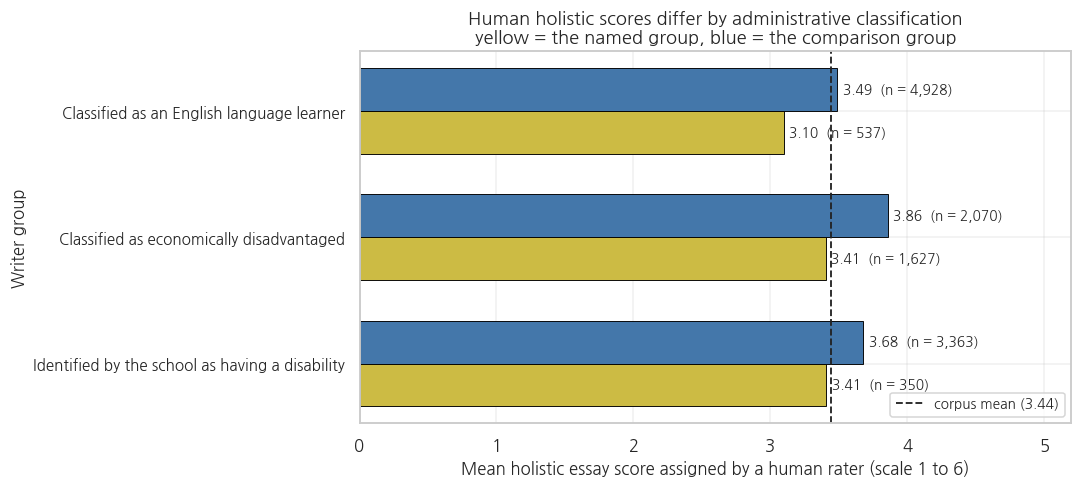

In [28]:
fig, ax = plt.subplots(figsize=(10, 4.6))

rows = [
    ('Classified as an English language learner', 3, 'Yes', 'No', ell_df, 'ell_status'),
    ('Classified as economically disadvantaged', 2, 'Economically disadvantaged',
     'Not economically disadvantaged', econ_df, 'economically_disadvantaged'),
    ('Identified by the school as having a disability', 1, 'Identified as having disability',
     'Not identified as having disability', dis_df, 'student_disability_status'),
]
h = 0.34
for label, y, focal, ref, df, col in rows:
    fa = df.loc[df[col] == focal, 'holistic_essay_score']
    fb = df.loc[df[col] == ref, 'holistic_essay_score']
    ax.barh(y + h / 2, fb.mean(), height=h, color=BLUE, edgecolor='black', linewidth=0.6)
    ax.barh(y - h / 2, fa.mean(), height=h, color=YELLOW, edgecolor='black', linewidth=0.6)
    ax.text(fb.mean() + 0.04, y + h / 2, f'{fb.mean():.2f}  (n = {len(fb):,})',
            va='center', fontsize=9)
    ax.text(fa.mean() + 0.04, y - h / 2, f'{fa.mean():.2f}  (n = {len(fa):,})',
            va='center', fontsize=9)

ax.set_yticks([r[1] for r in rows])
ax.set_yticklabels([r[0] for r in rows], fontsize=10)
ax.set_ylabel('Writer group')
ax.set_xlabel('Mean holistic essay score assigned by a human rater (scale 1 to 6)')
ax.set_xlim(0, 5.2)
ax.set_title('Human holistic scores differ by administrative classification\n'
             'yellow = the named group, blue = the comparison group')
ax.axvline(essays['holistic_essay_score'].mean(), color='#222222', linestyle='--',
           linewidth=1.2, label=f'corpus mean ({essays["holistic_essay_score"].mean():.2f})')
ax.legend(fontsize=9, loc='lower right')
plt.show()

**Let's look at the output.** The gaps in the scores raters assigned all run in the same direction, and none of them is large:

- Writers classified as English language learners average **3.10** (n = 537) against **3.49** for the rest (n = 4,928). Gap 0.39 points, Cohen's d = -0.33, 95 percent CI [-0.42, -0.24].
- Writers classified as economically disadvantaged average **3.41** (n = 1,627) against **3.86** (n = 2,070). Gap 0.45, d = -0.40, CI [-0.46, -0.33].
- Writers identified as having a disability average **3.41** (n = 350) against **3.68** (n = 3,363). Gap 0.27, d = -0.24, CI [-0.35, -0.13]. That interval is the widest of the three because the group has 350 essays in it.

This is an exercise in reading a recorded group difference carefully, not a finding about any group of writers. Two things are worth holding in view while reading the figure.

**What each variable records.** The axis plots **the score a human rater assigned**, disaggregated by **three labels a school system assigned**. Neither side is a property of a person. "English language learner" is an administrative classification; the file does not record the criteria, the reclassification rules, or the exit tests behind it, so the ELL bar pools students at unknown distances from whatever threshold was used. The economic and disability columns are likewise administrative records whose criteria the file does not carry.

**Group size and uncertainty.** The three focal groups hold 537, 1,627, and 350 essays. The intervals printed above are the appropriate thing to read before the point estimates, and the smallest group carries the widest one.

There is a strong version of the opposing reading, and it deserves stating. A skeptical reader could say: writing is hard, these groups face barriers in school, so of course the scores differ, and a holistic score is supposed to reflect the quality of the essay.  What the argument assumes without stating it is that the holistic score measures the essay and nothing else.

The next cells narrow the comparison to single moves. First, though, there is a methodological point that changes how the ELL number should be read.

**Run the cell below.**

In [29]:
print('The same ELL comparison, computed separately inside each prompt:')
within = ell_df.pivot_table(index='prompt_short', columns='ell_status',
                            values='holistic_essay_score', aggfunc=['mean', 'size'])
within.columns = ['mean (non-ELL)', 'mean (ELL)', 'n (non-ELL)', 'n (ELL)']
within['gap'] = (within['mean (ELL)'] - within['mean (non-ELL)']).round(3)
within['ELL share of prompt'] = (100 * within['n (ELL)'] /
                                 (within['n (ELL)'] + within['n (non-ELL)'])).round(1)
print(within.round(3).to_string())
print()
overall = (ell_df.loc[ell_df['ell_status'] == 'Yes', 'holistic_essay_score'].mean()
           - ell_df.loc[ell_df['ell_status'] == 'No', 'holistic_essay_score'].mean())
print(f'Gap computed on the whole corpus at once : {overall:+.3f}')
print(f'Smallest gap inside any single prompt    : {within["gap"].max():+.3f}')
print(f'Largest gap inside any single prompt     : {within["gap"].min():+.3f}')
print()
print('Two ways to summarize the four within-prompt gaps as one number, because')
print('"larger than the pooled gap" is worth putting a size on:')
print(f'   plain average of the four                          : '
      f'{within["gap"].mean():+.3f}')
print(f'   weighted by how many ELL-classified essays a prompt holds : '
      f'{np.average(within["gap"], weights=within["n (ELL)"]):+.3f}')
print(f'   ratio of each to the pooled gap                    : '
      f'{within["gap"].mean() / overall:.1f}x and '
      f'{np.average(within["gap"], weights=within["n (ELL)"]) / overall:.1f}x')
print()
print('Mean essay length in words, by ELL status:')
print(ell_df.groupby('ell_status')['essay_word_count'].mean().round(1).to_string())
print()
print('And the same, inside each prompt:')
print(ell_df.pivot_table(index='prompt_short', columns='ell_status',
                         values='essay_word_count', aggfunc='mean').round(1).to_string())

The same ELL comparison, computed separately inside each prompt:
                   mean (non-ELL)  mean (ELL)  n (non-ELL)  n (ELL)    gap  ELL share of prompt
prompt_short                                                                                   
cell phones                 3.077       2.588          795       34 -0.488                  4.1
distance learning           4.744       3.409         1124      374 -1.335                 25.0
driverless cars             3.235       2.655         1262       58 -0.579                  4.4
electoral college           3.051       2.070         1747       71 -0.981                  3.9

Gap computed on the whole corpus at once : -0.390
Smallest gap inside any single prompt    : -0.488
Largest gap inside any single prompt     : -1.335

Two ways to summarize the four within-prompt gaps as one number, because
"larger than the pooled gap" is worth putting a size on:
   plain average of the four                          : -0.846
   weighted by

**Let's look at the output.**

The corpus-wide ELL gap is **-0.39 points**. The gap inside every single prompt is **larger than that**: -0.49 for cell phones, -0.58 for driverless cars, -0.98 for the electoral college, and **-1.34** for distance learning.

How can the overall gap be smaller than every part of it? The last column shows why. **25 percent of the distance learning essays were written by ELL-classified students**, against about 4 percent everywhere else. And distance learning is the highest scoring prompt in the corpus (mean 4.41 against 3.01 for the electoral college). So ELL-classified writers are concentrated in the highest-scoring prompt, which is also the only prompt answered by grades 11 and 12, and that concentration masks most of the gap when the four are pooled.

This is the aggregation effect behind Simpson's paradox. A full reversal would be Simpson's paradox proper; here the sign holds and only the size changes, and the mechanism is the same: a group unevenly distributed across conditions, which in education is common. **Reporting the pooled number would have understated the gap by a factor of two to three, in an analysis that looked more careful than one that did not aggregate at all.** The printout gives both summaries so the range is visible: the plain average of the four within-prompt gaps is -0.85, which is 2.2 times the pooled -0.39, and weighting each prompt by how many ELL-classified essays it holds gives -1.15, which is 3.0 times. Neither is *the* right number. Which one you want depends on whether the question is about the four prompts or about these writers, and the choice needs saying.

The length rows underneath make the same point twice. Pooled, the two groups produce essays of almost identical length: **446 words against 448**. Inside each prompt, ELL-classified writers' essays are shorter in three of the four (483 against 621 under distance learning) and level in the fourth. Pooling does not reverse that comparison, it removes it: a 138-word difference inside the prompt where two thirds of the ELL-classified essays sit arrives as a 1.3-word difference overall. The feature most strongly associated with the score in this notebook becomes invisible the moment it is aggregated over a condition the two groups are unevenly spread across.

### One rhetorical move, held fixed

Essay scores are a summary judgment about a whole text, and whole texts differ in a hundred ways. 

One way to narrow it is to hold a single **rhetorical move** fixed and ask how it was rated. The annotator has already decided that this span is a student stating the opposing side's reason. That structural judgment is done. The remaining question is how well the rater thought it was executed.

**Run the two cells below.**

In [30]:
span_dem = rated.merge(
    essays[['essay_id', 'ell_status', 'economically_disadvantaged',
            'student_disability_status', 'prompt_short']],
    on='essay_id', how='left')
span_ell = span_dem[span_dem['ell_status'].isin(['Yes', 'No'])]

print(f'Rated spans whose writer has an ELL status recorded: {len(span_ell):,} '
      f'of {len(rated):,}')
print()
print('Percent of spans rated EFFECTIVE, by move and by ELL status:')
tab = pd.crosstab([span_ell['discourse_type'], span_ell['ell_status']],
                  span_ell['discourse_effectiveness'], normalize='index') * 100
counts = span_ell.groupby(['discourse_type', 'ell_status']).size()
tab['n spans'] = counts
print(tab[['Effective', 'Adequate', 'Ineffective', 'n spans']].round(1).to_string())
print()
print('Across every move at once:')
allmoves = pd.crosstab(span_ell['ell_status'], span_ell['discourse_effectiveness'],
                       normalize='index') * 100
allmoves['n spans'] = span_ell.groupby('ell_status').size()
print(allmoves[['Effective', 'Adequate', 'Ineffective', 'n spans']].round(1).to_string())

Rated spans whose writer has an ELL status recorded: 54,492 of 55,068

Percent of spans rated EFFECTIVE, by move and by ELL status:
discourse_effectiveness          Effective  Adequate  Ineffective  n spans
discourse_type       ell_status                                           
Claim                No               18.6      78.4          3.1    17048
                     Yes               5.6      89.3          5.1     1945
Concluding Statement No               23.6      72.6          3.8     4405
                     Yes              10.6      81.7          7.7      470
Counterclaim         No               17.1      79.3          3.6     2762
                     Yes               5.5      91.4          3.1      291
Evidence             No               21.9      70.4          7.6    15065
                     Yes               6.6      82.0         11.4     1645
Lead                 No               26.8      69.9          3.3     2902
                     Yes               8.1 

discourse_effectiveness  Effective  Adequate  Ineffective  n spans
ell_status                                                        
No                            19.9      75.5          4.6    49150
Yes                            6.2      86.6          7.2     5342


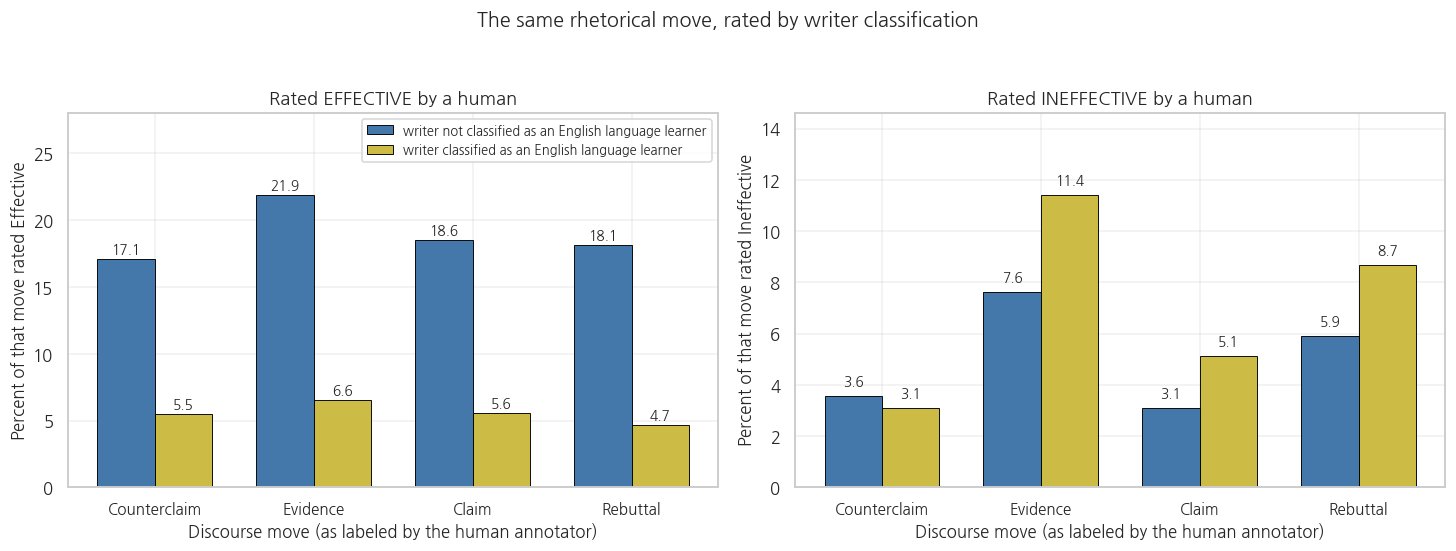

In [31]:
focus = ['Counterclaim', 'Evidence', 'Claim', 'Rebuttal']
eff = (pd.crosstab([span_ell['discourse_type'], span_ell['ell_status']],
                   span_ell['discourse_effectiveness'], normalize='index') * 100)

fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.8), sharey=False)
xs = np.arange(len(focus))
w = 0.36

for ax, outcome, ttl in zip(
        axes, ['Effective', 'Ineffective'],
        ['Rated EFFECTIVE by a human', 'Rated INEFFECTIVE by a human']):
    non = [eff.loc[(m, 'No'), outcome] for m in focus]
    ell = [eff.loc[(m, 'Yes'), outcome] for m in focus]
    ax.bar(xs - w / 2, non, width=w, color=BLUE, edgecolor='black', linewidth=0.6,
           label='writer not classified as an English language learner')
    ax.bar(xs + w / 2, ell, width=w, color=YELLOW, edgecolor='black', linewidth=0.6,
           label='writer classified as an English language learner')
    for x, v in zip(xs - w / 2, non):
        ax.text(x, v + 0.4, f'{v:.1f}', ha='center', fontsize=9)
    for x, v in zip(xs + w / 2, ell):
        ax.text(x, v + 0.4, f'{v:.1f}', ha='center', fontsize=9)
    ax.set_xticks(xs)
    ax.set_xticklabels(focus, fontsize=10)
    ax.set_xlabel('Discourse move (as labeled by the human annotator)')
    ax.set_ylabel(f'Percent of that move rated {outcome}')
    ax.set_title(ttl)
    ax.set_ylim(0, max(max(non), max(ell)) * 1.28)
axes[0].legend(fontsize=8.5, loc='upper right')
plt.suptitle('The same rhetorical move, rated by writer classification',
             fontsize=13, y=1.04)
plt.show()

### Before we read that figure

Those bars are percentages of **spans**, and spans are not independent of each other. The 5,342 spans written by ELL-classified writers come from 537 essays, one writer each as far as the file shows. All eleven or so spans inside one essay share that writer and that prompt, and presumably the same annotator, though the file does not record who annotated what.

An interval computed as though there were 5,342 independent observations would be built for a sample about four times larger than the one actually in hand. The next cell prints both widths so that factor is visible rather than asserted. The correction is: **resample essays rather than spans.** Draw 537 essays with replacement, take whatever spans come with each one, recompute, repeat.

**Run the cell below.**

In [32]:
# ---------------------------------------------------------------------------
# An essay-clustered bootstrap. Resample ESSAYS with replacement; each drawn
# essay brings all of its spans along. This is the honest unit here, because
# one essay is one writer on one day and its spans move together.
# ---------------------------------------------------------------------------
boot_rng = np.random.default_rng(RANDOM_STATE)


def clustered_gap(df, outcome, n_boot=2000):
    """ELL minus non-ELL in the percent of spans rated `outcome`, in percentage
    points, with a 95 percent interval built by resampling essays."""
    hit = (df['discourse_effectiveness'] == outcome).astype(int)
    per_essay = (pd.DataFrame({'essay': df['essay_id'].to_numpy(),
                               'ell': df['ell_status'].to_numpy(),
                               'hit': hit.to_numpy()})
                 .groupby(['ell', 'essay']).agg(k=('hit', 'sum'), n=('hit', 'size')))
    rate = {}
    for status in ['Yes', 'No']:
        k = per_essay.loc[status, 'k'].to_numpy()
        n = per_essay.loc[status, 'n'].to_numpy()
        pick = boot_rng.integers(0, len(k), (n_boot, len(k)))
        rate[status] = 100 * k[pick].sum(axis=1) / n[pick].sum(axis=1)
    point = 100 * (hit[df['ell_status'] == 'Yes'].mean()
                   - hit[df['ell_status'] == 'No'].mean())
    lo, hi = np.percentile(rate['Yes'] - rate['No'], [2.5, 97.5])
    return point, lo, hi


print('THE SAME COMPARISON, WITH AN INTERVAL THAT RESAMPLES ESSAYS')
print('(gap = ELL minus non-ELL in the percent of that move rated Effective)')
print()
print(f'  {"move":<22}{"spans, non-ELL / ELL":>24}{"essays, non-ELL / ELL":>24}'
      f'{"gap (pp)":>11}   95% interval')
for move in ['Lead', 'Position', 'Claim', 'Counterclaim', 'Rebuttal',
             'Evidence', 'Concluding Statement']:
    part = span_ell[span_ell['discourse_type'] == move]
    point, lo, hi = clustered_gap(part, 'Effective')
    ns = (f"{int((part['ell_status'] == 'No').sum()):,} / "
          f"{int((part['ell_status'] == 'Yes').sum()):,}")
    ne = (f"{part.loc[part['ell_status'] == 'No', 'essay_id'].nunique():,} / "
          f"{part.loc[part['ell_status'] == 'Yes', 'essay_id'].nunique():,}")
    print(f'  {move:<22}{ns:>24}{ne:>24}{point:>+11.1f}   [{lo:+.1f}, {hi:+.1f}]')

point, lo, hi = clustered_gap(span_ell, 'Effective')
print()
print(f'  {"every move together":<22}{"":>48}{point:>+11.1f}   [{lo:+.1f}, {hi:+.1f}]')
pt_i, lo_i, hi_i = clustered_gap(span_ell, 'Ineffective')
print(f'  {"the same, Ineffective":<22}{"":>48}{pt_i:>+11.1f}   [{lo_i:+.1f}, {hi_i:+.1f}]')

# And what the shortcut would have bought us.
hit_eff = (span_ell['discourse_effectiveness'] == 'Effective').astype(int)
a = hit_eff[span_ell['ell_status'] == 'Yes']
b = hit_eff[span_ell['ell_status'] == 'No']
naive_half = 1.96 * 100 * np.sqrt(a.var(ddof=1) / len(a) + b.var(ddof=1) / len(b))
print()
print('On the "every move together" line:')
print(f'  half-width of the interval above, resampling essays        : {(hi - lo) / 2:.2f} pp')
print(f'  half-width if all {len(span_ell):,} spans were treated as independent : '
      f'{naive_half:.2f} pp')
print('The second number is what treating spans as independent produces. It is')
print('too small, because 5,342 ELL spans come from 537 essays, not 5,342. Note also')
print('that the wider interval still does not come close to zero: the clustered')
print('interval is wider and still excludes zero.')


THE SAME COMPARISON, WITH AN INTERVAL THAT RESAMPLES ESSAYS
(gap = ELL minus non-ELL in the percent of that move rated Effective)

  move                      spans, non-ELL / ELL   essays, non-ELL / ELL   gap (pp)   95% interval


  Lead                               2,902 / 308             2,901 / 308      -18.7   [-22.0, -15.0]


  Position                           4,916 / 533             4,902 / 531      -10.3   [-12.0, -8.5]
  Claim                           17,048 / 1,945             4,778 / 517      -12.9   [-14.7, -11.2]
  Counterclaim                       2,762 / 291             2,071 / 213      -11.6   [-14.7, -7.7]


  Rebuttal                           2,052 / 150             1,628 / 133      -13.5   [-17.8, -8.1]


  Evidence                        15,065 / 1,645             4,913 / 535      -15.4   [-17.3, -13.3]


  Concluding Statement               4,405 / 470             4,375 / 470      -13.0   [-16.0, -9.8]

  every move together                                                         -13.7   [-15.1, -12.2]


  the same, Ineffective                                                        +2.7   [+1.4, +4.0]

On the "every move together" line:
  half-width of the interval above, resampling essays        : 1.43 pp
  half-width if all 54,492 spans were treated as independent : 0.74 pp
The second number is what treating spans as independent produces. It is
too small, because 5,342 ELL spans come from 537 essays, not 5,342. Note also
that the wider interval still does not come close to zero: the clustered
interval is wider and still excludes zero.


**Let's look at the output.**



Among spans that a human annotator had already identified as a **Counterclaim**, and therefore already credited as the student having produced a counterclaim:

- **17.1 percent** of those written by non-ELL-classified students were rated Effective (2,762 spans, 2,071 essays).
- **5.5 percent** of those written by ELL-classified students were rated Effective (291 spans, 213 essays, which is sixteen spans in total).
- The gap is **-11.6 percentage points**, 95 percent interval **[-14.7, -7.7]**, resampling essays rather than spans.

Among **Evidence** spans:

- **21.9 percent** effective for non-ELL-classified writers (15,065 spans, 4,913 essays) against **6.6 percent** for ELL-classified writers (1,645 spans, 535 essays). Gap **-15.4**, 95 percent **[-17.3, -13.3]**.
- And the Ineffective ratings run the other way: **7.6 percent** against **11.4 percent**.

Across all moves together: writers not classified as ELL get **19.9 percent** Effective and **4.6 percent** Ineffective (49,150 spans from 4,928 essays). Writers classified as ELL get **6.2 percent** Effective and **7.2 percent** Ineffective (5,342 spans from 537 essays). The Effective gap is **-13.7 points, 95 percent [-15.1, -12.2]**, the Ineffective gap **+2.7, 95 percent [+1.4, +4.0]**, and all seven per-move intervals fall on the same side of zero.

The interval nearly doubled in width once essays were resampled instead of spans, from a half-width of 0.74 points to 1.43, which is what acknowledging that 5,342 spans come from 537 essays changes. It also left the finding standing. What no interval can do is say *why* the ratings differ.

This is not the essay score. The structural work is already credited. The move is on the page and the annotator has named it. What differs is the judgment of how well it was done.

| | |
|---|---|
| **What the data directly show** | Among spans a human had already named as a given move, spans by ELL-classified writers were rated Effective less often: 6.2 percent against 19.9 percent across all moves, gap -13.7 points, 95 percent essay-clustered interval [-15.1, -12.2], on 5,342 spans from 537 essays against 49,150 spans from 4,928 essays. All seven per-move intervals fall on the same side of zero. |
| **A plausible interpretation** | Raters responded to surface features of second-language writing; the rubric encodes a norm about what a good argument sounds like; the conditions of schooling and testing differed across the two groups; the moves were executed less fluently. |
| **What this file cannot establish** | Which of these is operating, or in what mixture. The corpus carries no rater identifiers, no blind-scored subset, no second rubric, and no schooling history. |

### Competing readings, and why this file cannot choose between them

The readings below are in the order this course takes them: what the instrument did, what the construct did, what the file does not record, and only then anything about the writers.

1. **The instrument.** "Effective" is a judgment a person made, under a rubric, on writing whose surface carries traces of its writer. Under this reading, features common in second-language writing (article choice, unusual collocations, prepositions) are salient to a reader and pull global judgments of quality even when raters are instructed to set them aside. Under this reading the ratings are contaminated and the error runs in one direction.
2. **The construct.** "Effective" is defined by a rubric written by somebody, and a rubric encodes a norm about what a good argument sounds like. Under this reading nobody made an error at all: the gap is the rubric doing what it was designed to do, applied to students whose rhetoric was not what it was designed around.
3. **The setting and the circumstances.** This file records a score, five demographic fields, and a grade level that is confounded with prompt. It does not record how much of the period the student had left, whether they had a testing accommodation, how long they had been in an English-medium school, what writing instruction they had received, or what "ELL" means in the district that applied the label. That last one carries weight: ELL is an administrative classification whose criteria this file does not record, so a gap between ELL and non-ELL is partly a fact about a classification system.
4. **The writing.** A student writing in a language they are still acquiring may produce counterclaims that are structurally present and less fluently executed, and a rater noticing that is doing their job. Notice only that it is fourth rather than first, and that this file gives no more evidence for it than for the other three.

Reading 1 points at the raters. Reading 2 points at the construct. Reading 3 points at the conditions, and at the habit of treating a district label as a property of a child. Reading 4 points at instruction. They are not mutually exclusive, and this file cannot weigh them. **Distinguishing among them would need rater-level identifiers, essays scored blind to writer status, a second panel working from a different rubric, or the schooling history this corpus does not carry.** None of those are here.

What may **not** be concluded on this evidence is that these students write worse. That sentence requires the instrument to be neutral. The next cell checks whether the gap holds inside each prompt, and how far the rating distribution moves across prompts.

The readings this week supply the vocabulary. **Allen, Creer, and Öncel** on the multi-dimensionality of language as evidence. **Gibson and Shibani** on the distance between what a writing analytics tool measures and what a teacher should be handed. **Dowell and Kovanović** on discourse as structure rather than surface. Take a position in the memo and say what supports it. "More research is needed" is not a position.

**Run the cell below.**

In [33]:
# Section 7 has been pooling across four prompts. Section 7's own Simpson's
# paradox detour is the reason we cannot leave it there, so run the same
# comparison one prompt at a time and see whether the finding survives.
per_prompt = (pd.crosstab([span_ell['prompt_short'], span_ell['ell_status']],
                          span_ell['discourse_effectiveness'], normalize='index') * 100)
per_prompt['n spans'] = span_ell.groupby(['prompt_short', 'ell_status']).size()
print('Every rated span, split by prompt and by ELL classification:')
print(per_prompt[['Effective', 'Adequate', 'Ineffective', 'n spans']].round(1).to_string())
print()

wide = per_prompt['Effective'].unstack()
wide.columns = ['non-ELL % Effective', 'ELL % Effective']
wide['gap (pp)'] = (wide['ELL % Effective'] - wide['non-ELL % Effective'])
pooled_gap = allmoves.loc['Yes', 'Effective'] - allmoves.loc['No', 'Effective']
print(wide.round(1).to_string())
print()
print(f'Pooled over all four prompts, the gap is {pooled_gap:+.1f} percentage points.')
print(f'Inside a single prompt it runs from {wide["gap (pp)"].max():+.1f} to '
      f'{wide["gap (pp)"].min():+.1f}, and it is negative in all four.')
print()
print('Now hold the classification constant and read ONE group down the prompts.')
print('Every row below is writers NOT classified as ELL. Only the prompt changes:')
one_group = per_prompt.xs('No', level='ell_status')[['Effective', 'Ineffective', 'n spans']]
print(one_group.round(1).to_string())


Every rated span, split by prompt and by ELL classification:
discourse_effectiveness       Effective  Adequate  Ineffective  n spans
prompt_short      ell_status                                           
cell phones       No                5.4      91.4          3.1     6834
                  Yes               0.4      92.1          7.5      240
distance learning No               31.1      68.4          0.5    14439
                  Yes               6.2      88.8          5.0     4087
driverless cars   No               15.9      82.8          1.3    11579
                  Yes               6.8      88.4          4.9      473
electoral college No               18.9      70.0         11.1    16298
                  Yes               8.5      65.3         26.2      542

                   non-ELL % Effective  ELL % Effective  gap (pp)
prompt_short                                                     
cell phones                        5.4              0.4      -5.0
distance learning   

**Let's look at the output.**

**First, the finding survives.** The pooled gap is **-13.7 percentage points**. Inside a single prompt it runs from **-5.0** (cell phones) to **-24.9** (distance learning), and it is negative in all four. Unlike the essay scores, the pooled gap sits inside the range of the four within-prompt gaps; the largest, -24.9, is in the prompt that holds 4,087 of the 5,342 ELL-classified spans. Had the within-prompt gaps pointed in different directions, the headline figure above would have been an artifact and would have had to be withdrawn. They do not, so it stands.

**Second, the last table**, where the ELL classification is held constant and only the prompt changes. Within the single group of writers **not** classified as ELL, the share of spans rated Effective runs from **5.4 percent** under the cell phone prompt to **31.1 percent** under distance learning. The share rated Ineffective runs from **0.5 percent** under distance learning to **11.1 percent** under the electoral college, a difference of more than twenty-fold.

What that does and does not establish: These are different students in different rows, so this is **not** a within-person comparison and it does not show that the raters differed. What it does establish is that the output of this three-point scale moves a great deal with which prompt a span came from. Several candidate causes are tangled here and this file separates none of them: different prompts, different source material, different grade levels (each prompt was answered by a different grade), and whatever differences in testing session or rating panel the release does not document.

A rating whose distribution moves this far across prompts is difficult to treat as a neutral measure of writing quality. Any explanation of the ELL gap that starts with the writers leaves out a source of variation larger than the gap it is trying to explain.

**Run the cell below.**

In [34]:
# Now connect Section 6 to Section 7: how does the effectiveness model
# distribute its errors?
te2_dem = te2.merge(essays[['essay_id', 'ell_status']], on='essay_id', how='left')
sub = te2_dem[te2_dem['ell_status'].isin(['Yes', 'No'])]

print('THE MODEL YOU TRAINED IN SECTION 6, AUDITED BY WRITER GROUP')
print()
rows = []
for g, name in [('No', 'writer not classified as ELL'), ('Yes', 'writer classified as ELL')]:
    s = sub[sub['ell_status'] == g]
    rows.append({
        'group': name,
        'test spans': len(s),
        'rated Effective': int(s['is_effective'].sum()),
        'human Effective rate': f"{100 * s['is_effective'].mean():.1f}%",
        'model flag rate': f"{100 * s['pred_effective'].mean():.1f}%",
        'recall (of the spans rated Effective, found)':
            f"{100 * recall_score(s['is_effective'], s['pred_effective']):.1f}%",
    })
print(pd.DataFrame(rows).to_string(index=False))
print()
def clustered_recall(df, n_boot=2000):
    """Percent of the spans rated Effective that the model flagged, with a 95
    percent interval built by resampling essays rather than spans."""
    truly = df[df['is_effective'] == 1]
    per_essay = (pd.DataFrame({'essay': truly['essay_id'].to_numpy(),
                               'hit': truly['pred_effective'].to_numpy()})
                 .groupby('essay').agg(k=('hit', 'sum'), n=('hit', 'size')))
    k, n = per_essay['k'].to_numpy(), per_essay['n'].to_numpy()
    pick = boot_rng.integers(0, len(k), (n_boot, len(k)))
    draws = 100 * k[pick].sum(axis=1) / n[pick].sum(axis=1)
    lo, hi = np.percentile(draws, [2.5, 97.5])
    return 100 * truly['pred_effective'].mean(), lo, hi, len(truly), truly['essay_id'].nunique()


print('THE SAME TWO RECALLS WITH AN INTERVAL ON EACH')
for g, name in [('No', 'writer not classified as ELL'), ('Yes', 'writer classified as ELL')]:
    r, lo, hi, ns, ne = clustered_recall(sub[sub['ell_status'] == g])
    print(f'  {name:<26} {r:>5.1f}%   95% [{lo:.1f}%, {hi:.1f}%]   '
          f'from {ns:,} effective spans in {ne:,} essays')
print()
print('The ELL interval is wide. Anyone who quotes the point estimate alone is')
print('reporting a number this file cannot pin down that precisely. What the file')
print('supports is the two recalls with their intervals; no test of the difference is run here.')

THE MODEL YOU TRAINED IN SECTION 6, AUDITED BY WRITER GROUP



                       group  test spans  rated Effective human Effective rate model flag rate recall (of the spans rated Effective, found)
writer not classified as ELL       12267             2445                19.9%           10.4%                                        31.8%
    writer classified as ELL        1363               88                 6.5%            3.3%                                        14.8%

THE SAME TWO RECALLS WITH AN INTERVAL ON EACH
  writer not classified as ELL  31.8%   95% [29.8%, 33.9%]   from 2,445 effective spans in 1,418 essays
  writer classified as ELL    14.8%   95% [7.3%, 23.2%]   from 88 effective spans in 60 essays

The ELL interval is wide. Anyone who quotes the point estimate alone is
reporting a number this file cannot pin down that precisely. What the file
supports is the two recalls with their intervals; no test of the difference is run here.


**Let's look at the output.**

The model finds **31.8 percent** of the spans rated Effective written by non-ELL-classified students, 95 percent interval **[29.8, 33.9]**, and **14.8 percent** of those written by ELL-classified students, 95 percent interval **[7.3, 23.2]**. It flags ELL-classified students' writing as effective at **3.3 percent** against **10.4 percent**.

Please read the second interval before quoting the second number. It rests on 88 spans rated Effective, from 60 essays. This file can support "on this test set the model recovers a smaller share of these writers' spans rated Effective." It cannot support "one in seven" as a precise figure, because the interval stretches from roughly one in fourteen to roughly one in four. 

The sequence:

1. Human raters called ELL-classified students' moves Effective about a third as often (Section 7).
2. A bag-of-words model was trained on those labels (Section 6).
3. The model reproduces that pattern: it flags 3.3 percent of ELL-classified writers' spans against 10.4 percent.
4. Deployed as feedback, it would tell ELL-classified students they had written something effective about a seventh as often as the human raters did, with the interval on that running from about one in fourteen to about one in four.

**Nobody put a demographic variable in this model.** There is no `ell_status` column in the feature matrix. The features are counts of English words. And in Section 5 an unsupervised topic model already partly recovered ELL status from word counts alone, without being asked to.

This is the week's central limitation, made concrete: an automated writing scorer trained on these labels inherits this pattern without any output indicating it, and its accuracy number stays at 83 percent throughout.

One more qualification. The model's flag rates, 3.3 against 10.4 percent, stand in about the same ratio as the human rates, 6.2 against 19.9. The two recalls, 14.8 against 31.8, are closer together, because the model flags few spans for anyone. A model that flags almost nothing as effective for anyone is a different thing, and not an improvement.

*Connecting to the readings.* Gibson and Shibani (2022) are concerned with the distance between what a writing analytics tool measures and what should actually reach a teacher or a student. This audit is a way of measuring that distance: the number a vendor would show is 83 percent accuracy, and the number a student would experience is a recall of 14.8 percent with an interval from 7.3 to 23.2. Which of those you would hand to a fourteen-year-old, and what you would say alongside it, is a good question for the memo.

---

## 8. Going further (optional): does the pattern hold for other groups and other moves?

*Optional. The deliverable is complete without it.*

Section 7 examined one grouping variable, ELL classification, across all seven moves. The next question is whether the pattern is specific to language status or whether any grouping of students produces gaps like this. That is a checkable question.

### Your turn 5: pick a group and a move

`GROUP_COLUMN` and `MOVE` below default to `economically_disadvantaged` and `Evidence`. Any of these will run:

- `GROUP_COLUMN`: `'economically_disadvantaged'`, `'student_disability_status'`, `'gender'`, `'ell_status'`, `'race_ethnicity'`
- `MOVE`: any of `Claim`, `Evidence`, `Position`, `Counterclaim`, `Rebuttal`, `Lead`, `Concluding Statement`

Try `gender` as well.

Move: Evidence   |   Grouping: economically_disadvantaged
Spans used: 11,523. Spans dropped because the field was blank: 5,365

discourse_effectiveness         Effective  Adequate  Ineffective  n spans
economically_disadvantaged                                               
Economically disadvantaged           15.1      80.6          4.3     4917
Not economically disadvantaged       26.6      71.4          1.9     6606

Spread in the Effective rate across groups: 11.5 percentage points



"Economically disadvantaged" minus "Not economically disadvantaged", in the percent rated Effective:
   -11.5 percentage points, 95% [-13.8, -9.3], resampling essays
   Essays behind those spans: 1,627 and 2,069
   Prompts these spans come from: cell phones, distance learning, driverless cars


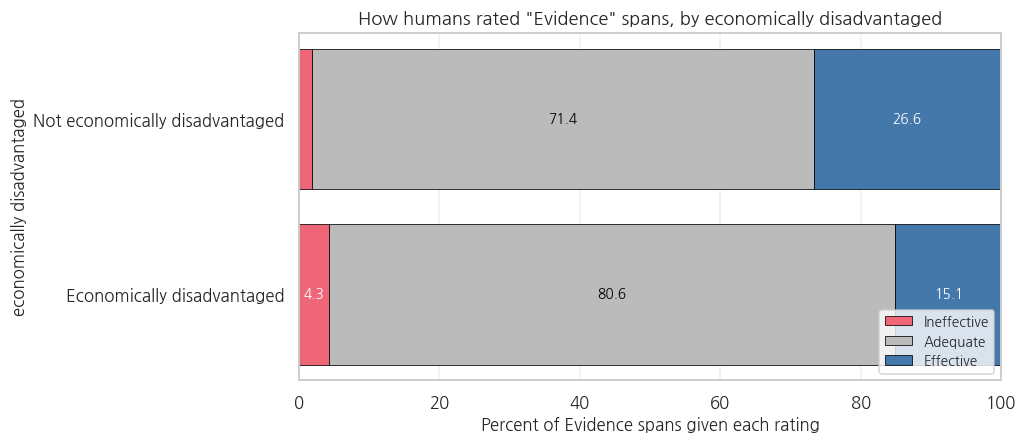

In [35]:
# TODO (optional): change either of these two values and re-run.
GROUP_COLUMN = 'economically_disadvantaged'
MOVE = 'Evidence'

sel = span_dem[span_dem['discourse_type'] == MOVE].copy()
sel = sel[sel[GROUP_COLUMN].notna() &
          (sel[GROUP_COLUMN].astype(str).str.strip() != '')]

tab = pd.crosstab(sel[GROUP_COLUMN], sel['discourse_effectiveness'],
                  normalize='index') * 100
tab['n spans'] = sel.groupby(GROUP_COLUMN).size()
tab = tab[['Effective', 'Adequate', 'Ineffective', 'n spans']].round(1)

print(f'Move: {MOVE}   |   Grouping: {GROUP_COLUMN}')
print(f'Spans used: {len(sel):,}. '
      f'Spans dropped because the field was blank: '
      f'{int((span_dem["discourse_type"] == MOVE).sum()) - len(sel):,}')
print()
print(tab.to_string())
print()
spread = tab['Effective'].max() - tab['Effective'].min()
print(f'Spread in the Effective rate across groups: {spread:.1f} percentage points')
print()

# Same discipline as Section 7: spans come in essay-sized clumps, so resample essays.
levels = list(tab.index)
if len(levels) == 2:
    focal, ref = levels
    hit = (sel['discourse_effectiveness'] == 'Effective').astype(int)
    per_essay = (pd.DataFrame({'essay': sel['essay_id'].to_numpy(),
                               'g': sel[GROUP_COLUMN].to_numpy(),
                               'hit': hit.to_numpy()})
                 .groupby(['g', 'essay']).agg(k=('hit', 'sum'), n=('hit', 'size')))
    draw = {}
    for g in (focal, ref):
        k = per_essay.loc[g, 'k'].to_numpy()
        n = per_essay.loc[g, 'n'].to_numpy()
        pick = boot_rng.integers(0, len(k), (2000, len(k)))
        draw[g] = 100 * k[pick].sum(axis=1) / n[pick].sum(axis=1)
    lo, hi = np.percentile(draw[focal] - draw[ref], [2.5, 97.5])
    point = 100 * (hit[sel[GROUP_COLUMN] == focal].mean()
                   - hit[sel[GROUP_COLUMN] == ref].mean())
    print(f'"{focal}" minus "{ref}", in the percent rated Effective:')
    print(f'   {point:+.1f} percentage points, 95% [{lo:+.1f}, {hi:+.1f}], resampling essays')
    print(f'   Essays behind those spans: '
          f'{sel.loc[sel[GROUP_COLUMN] == focal, "essay_id"].nunique():,} and '
          f'{sel.loc[sel[GROUP_COLUMN] == ref, "essay_id"].nunique():,}')
    print(f'   Prompts these spans come from: '
          f'{", ".join(sorted(sel["prompt_short"].unique()))}')
else:
    print(f'{len(levels)} groups here, so no two-group interval is printed. With this many')
    print('cells, describe the gradient across them rather than hunting the largest single')
    print('gap, and check the span counts before you believe any of the small ones.')

groups = list(tab.index)
fig, ax = plt.subplots(figsize=(9.5, 0.9 * len(groups) + 2.4))
left = np.zeros(len(groups))
for col, colr in [('Ineffective', ROSE), ('Adequate', GREY), ('Effective', BLUE)]:
    ax.barh(groups, tab[col], left=left, color=colr, edgecolor='black',
            linewidth=0.5, label=col)
    for y, (v, l) in enumerate(zip(tab[col], left)):
        if v > 3:
            ax.text(l + v / 2, y, f'{v:.1f}', ha='center', va='center', fontsize=9,
                    color='white' if col != 'Adequate' else 'black')
    left = left + tab[col].values
ax.set_xlabel(f'Percent of {MOVE} spans given each rating')
ax.set_ylabel(GROUP_COLUMN.replace('_', ' '))
ax.set_title(f'How humans rated "{MOVE}" spans, by {GROUP_COLUMN.replace("_", " ")}')
ax.set_xlim(0, 100)
ax.legend(fontsize=9, loc='lower right')
plt.show()

In [36]:
# Four more comparisons for the notes on Your turn 5, computed the same way as the cell
# above, so the appendix quotes printed numbers. This cell comes after the one above so
# that the draws from boot_rng used there are unchanged.
span_all = rated.merge(
    essays[['essay_id', 'gender', 'ell_status', 'economically_disadvantaged',
            'student_disability_status', 'prompt_short']],
    on='essay_id', how='left')


def group_move_gap(column, move, focal, ref, prompts=None):
    s = span_all[span_all['discourse_type'] == move]
    s = s[s[column].notna() & (s[column].astype(str).str.strip() != '')]
    if prompts is not None:
        s = s[s['prompt_short'].isin(prompts)]
    hit = (s['discourse_effectiveness'] == 'Effective').astype(int)
    per_essay = (pd.DataFrame({'essay': s['essay_id'].to_numpy(), 'g': s[column].to_numpy(),
                               'hit': hit.to_numpy()})
                 .groupby(['g', 'essay']).agg(k=('hit', 'sum'), n=('hit', 'size')))
    draw = {}
    for g in (focal, ref):
        k = per_essay.loc[g, 'k'].to_numpy()
        n = per_essay.loc[g, 'n'].to_numpy()
        pick = boot_rng.integers(0, len(k), (2000, len(k)))
        draw[g] = 100 * k[pick].sum(axis=1) / n[pick].sum(axis=1)
    lo, hi = np.percentile(draw[focal] - draw[ref], [2.5, 97.5])
    rf = 100 * hit[s[column] == focal].mean()
    rr = 100 * hit[s[column] == ref].mean()
    nf, nr = int((s[column] == focal).sum()), int((s[column] == ref).sum())
    ef = s.loc[s[column] == focal, 'essay_id'].nunique()
    er = s.loc[s[column] == ref, 'essay_id'].nunique()
    label = f'{column} on {move}' + (f', {len(prompts)} prompts only' if prompts else '')
    print(label)
    print(f'  {focal}: {rf:.1f}% Effective ({nf:,} spans, {ef:,} essays)   '
          f'{ref}: {rr:.1f}% ({nr:,} spans, {er:,} essays)')
    print(f'  gap {rf - rr:+.1f} points, 95% [{lo:+.1f}, {hi:+.1f}], resampling essays')
    print()


print('FOUR MORE COMPARISONS, FOR THE NOTES ON YOUR TURN 5')
print()
group_move_gap('gender', 'Evidence', 'F', 'M')
group_move_gap('gender', 'Evidence', 'F', 'M',
               prompts=['cell phones', 'distance learning', 'driverless cars'])
group_move_gap('student_disability_status', 'Counterclaim',
               'Identified as having disability', 'Not identified as having disability')
group_move_gap('student_disability_status', 'Evidence',
               'Identified as having disability', 'Not identified as having disability')
print('Essays per race_ethnicity category, for the caution in the notes:')
print(essays['race_ethnicity'].value_counts().to_string())


FOUR MORE COMPARISONS, FOR THE NOTES ON YOUR TURN 5



gender on Evidence
  F: 22.5% Effective (8,917 spans, 2,840 essays)   M: 17.9% (7,971 spans, 2,674 essays)
  gap +4.6 points, 95% [+2.8, +6.5], resampling essays



gender on Evidence, 3 prompts only
  F: 24.2% Effective (6,116 spans, 1,922 essays)   M: 18.7% (5,456 spans, 1,790 essays)
  gap +5.6 points, 95% [+3.2, +8.0], resampling essays



student_disability_status on Counterclaim
  Identified as having disability: 11.5% Effective (183 spans, 135 essays)   Not identified as having disability: 16.0% (1,829 spans, 1,381 essays)
  gap -4.5 points, 95% [-10.5, +2.1], resampling essays

student_disability_status on Evidence
  Identified as having disability: 16.1% Effective (1,096 spans, 349 essays)   Not identified as having disability: 22.2% (10,476 spans, 3,363 essays)
  gap -6.0 points, 95% [-9.5, -2.7], resampling essays

Essays per race_ethnicity category, for the caution in the notes:
race_ethnicity
White                             2456
Hispanic/Latino                   1472
Black/African American            1000
Asian/Pacific Islander             385
Two or more races/Other            194
American Indian/Alaskan Native      24


**Let's look at the output.** With the shipped defaults, `Evidence` spans by writers classified as economically disadvantaged were rated Effective **15.1 percent** of the time (4,917 spans, 1,627 essays) against **26.6 percent** for the rest (6,606 spans, 2,069 essays), and Ineffective **4.3 percent** against **1.9 percent**. The gap is **-11.5 points, 95 percent [-13.8, -9.3]**, resampling essays as Section 7 did. That is the same shape as the ELL result, on a different column.

The cell below the figure prints four more comparisons the same way. Change `GROUP_COLUMN` to `'gender'` and re-run to see the first of them in full. The Effective rate for `Evidence` is 22.5 percent for F and 17.9 percent for M (8,917 and 7,971 spans, from 2,840 and 2,674 essays), a gap of **+4.6 points**, 95 percent interval **[+2.8, +6.5]**, as the cell above prints. It is distinguishable from zero, it is smaller than half the economic gap, and it runs in the opposite direction.

**One caution before setting those two numbers side by side.** They are not computed on the same corpus. Economic status is blank for every electoral college essay, so the economic comparison rests on three prompts; gender is recorded everywhere, so the gender comparison rests on four. The cell prints the prompt list under each result for exactly that reason. Restricting gender to the same three prompts moves it to +5.6, interval [+3.2, +8.0], which does not change the conclusion.

**The gaps are not all the same size. The largest fall on the ELL, economic and disability classifications, and the gender gap is smaller and runs the other way.** Which is why "the raters were reading the writer" and "these students had different opportunities to learn" are both still live, and why a column that shows a gap is evidence for neither on its own. Note also that both of those explanations sit outside the student: one is about the instrument, one is about the school.

And one arithmetic caution applies to the whole of Section 8. Five grouping columns times seven moves is thirty-five comparisons available from this one cell. Running them all and reporting the biggest finds the largest of thirty-five numbers, which is not the same thing as a finding. Choose the comparison before you look, or say how many you ran.

To push further: try `student_disability_status` on `Counterclaim`. That is 183 spans from 135 essays in one group, the gap is -4.5 points, and its interval runs from -10.5 to +2.1. It contains zero. The appropriate report is "we cannot distinguish this from noise on 183 spans," not the point estimate on its own.

---

## Reflection and the interpretation memo

### Tie it to the readings

This week's required readings all argue, in different registers, that language is a legitimate and difficult source of evidence about learning.

- **Allen, Creer, and Öncel (2022)** make the case for a multi-dimensional view of learning through natural language processing: no single index of a text captures what a learner is doing. Several indices were built in this notebook (a stance lexicon, a word count, a topic assignment, two classifiers), and the crudest one was the strongest. Is that the multi-dimensionality these authors describe, or a warning that the dimensions we can measure easily are not the ones that matter? Either answer is defensible if you argue for it.
- **Gibson and Shibani (2022)** write about writing analytics and about the distance between what a tool measures and what a teacher should actually be handed. Take one number from this notebook, any number, and ask whether you would show it to the fourteen-year-old who wrote the essay. If not, why was it computed? If yes, what would you say alongside it?
- **Dowell and Kovanović (2022)** model educational discourse as a social and structural process rather than a bag of words. Section 6 gives a sharp illustration: the classifier recovers Position and Evidence, which are defined by their own content, and does worst on Counterclaim and Rebuttal, which are defined by their relationship to other moves. What is one thing their approach can see that a span-level bag of words structurally cannot?
- **Dowell, Lin, Godfrey, and Brooks (2020)**, in the additional readings, connect emergent sociocognitive roles to collaborative outcomes. If you wanted to extend this notebook toward roles rather than moves, what would you need beyond an essay corpus?

Our guest this week is **Jiayi (Joyce) Zhang** of Worcester Polytechnic Institute. It may be useful to bring a question from your own analysis rather than a generic one. 

### Questions to sit with

1. Section 1 showed that one third of this corpus is missing economic and disability status, and that the hole is exactly one prompt. You made a decision about it. Somebody upstream made a decision before you. Which of the two decisions has more effect on what can be concluded, and which one is documented?
2. Of the features computed in this notebook, the one most strongly associated with the holistic score is **how many words the student wrote** (r = 0.559, rho = 0.753). Is that a fact about writing, a fact about raters, or a fact about testing conditions? What would you need in order to tell?
3. You trained a model that reports 83.4 percent accuracy and misses 69 percent of the effective writing. If a vendor showed you the first number, what is the exact question you would ask to get to the second?
4. These essays were written by children in a testing session and released for research. Several sections of this notebook computed group differences in how their writing was judged. Write down one thing you would be unwilling to publish from this analysis, and who you would be protecting.
5. Suppose all four readings of the Section 7 finding are partly true. What would a responsible district do next?

### Your interpretation memo (about 300 words)

**Please write it in the cell below.** Double-click the cell to edit it, replace the bracketed prompts, and keep the headings. This memo is the primary component used for grading, and it is where the analytical work of the mini project lives.

### Interpretation memo

**Your name:**
**Date:**

**What I found.**
[Two or three sentences on the substantive result. What is true of this corpus? Use at least two specific numbers from this notebook and say which cell produced each.]

**The finding I had to interpret.**
[Take the Section 7 result. Which of the four readings do you find most credible, and why? What specific evidence in the notebook supports your choice, and what evidence cuts against it? Say explicitly what a reader who chose a different reading would conclude and why you set it aside. "More research is needed" is not a position.]

**What my choices did to my results.**
[Name two decisions you made in this notebook: your stopword list, your lexicon edits, your number of topics, the choice to collapse effectiveness to two categories, the choice to split spans at random rather than by essay, or the choice to drop rather than impute the missing demographic fields. For each, state what a different reasonable choice would have changed.]

**Limits, ethics, and equity.**
[Who is missing from this analysis, and what does that do to the claim? Size at least one limitation rather than only naming it. Then: if a district asked you to build a writing scorer on this corpus, what would you tell them, and what would you decline to hand over?]

---

## Submission checklist: Mini Project 2

**Due via Canvas by 11:59 PM on Sunday, September 27, 2026.** We open this notebook together in class on September 23, from 3:30 to 4:20 PM, and the debrief block from 5:30 to 5:50 leaves time to return to it. Finishing at home afterwards is expected.

All three parts below are required for full credit. Coding skill is not what is assessed; the interpretation memo is the primary component used for grading.

**1. The notebook.** Upload the executed `.ipynb` file, with the outputs visible, to the **Mini Project 2** assignment on Canvas.
- [ ] Runs top to bottom without errors (use **Runtime > Restart session and run all** and watch it go).
- [ ] All five **Your turn** cells attempted, even if you kept a default and explained why in a comment.
- [ ] Every figure still has a readable title and axis labels after your edits.
- [ ] Anywhere you report a number about a group, the sample size is next to it.

**2. The interpretation memo (about 300 words).** Completed in the markdown cell above, inside the notebook. If you would rather submit it as a separate document, that is fine, but it needs to be in the notebook as well, so the numbers you cite sit next to the code that produced them.

**3. The AI interaction log and reflection.** Goes to the Canvas **AI Reflection** submission, in two different places on that page.
- [ ] **The conversation record in an attached Word file.** Every relevant exchange, across every session and every tool, pasted in full. Not a summary, not a link.
- [ ] **The reflection in the Canvas text box.** Copy in the four questions from the syllabus and answer each: how you used AI; whether it helped and how; whether it made your work more challenging in any way; and what lesson about AI from this week you would pass on to a friend or the class.
- [ ] If you used no AI at all, say so in one line in the text box and attach nothing. A blank submission is not a declaration.
- Undisclosed or inappropriate AI use is an Honor Code violation. Disclosed, policy-compliant use is not penalized.

**A note specific to this week.** Text analysis is unusually easy to have an AI do for you and unusually easy to get subtly wrong. If a model writes your lexicon, names your topics, or drafts your interpretation of the Section 7 gap, please say so, and then do the thing the model cannot do: open the spans, read what the students actually wrote, and check whether the interpretation survives contact with them. That checking is the assignment.

**And a note about the data.** These are real essays by real children, released under CC BY-NC-SA 4.0 for research and education. Please cite the corpus in your memo (Crossley et al., 2024). Do not redistribute the text, do not use it commercially, and do not quote a long passage of a student's essay in anything public. Short illustrative spans, as the notebook prints them, are used here for coursework under the license.

---

## Appendix: notes on the Your turn cells

These are notes on what each exercise was for rather than answer keys, because in every case more than one answer is defensible. They may be most useful after you have tried the cells.

### Your turn 1: corpus-specific stopwords

The shipped default removes `just, like, dont, im, people, thing, things, say, said, know, want, going`. A version aimed harder at topic separation would also remove the four prompts' shared institutional vocabulary:

```python
MY_EXTRA_STOPWORDS = ['just', 'like', 'dont', 'im', 'people', 'thing', 'things',
                      'say', 'said', 'know', 'want', 'going',
                      'students', 'student', 'school', 'schools', 'think', 'good', 'bad']
```

**The trade to notice.** Removing `students` and `school` takes out two words that appear in nearly every cell phone and distance learning essay and almost never in the other two prompts; they separate those two prompts from the rest and do nothing to separate them from each other. It also deletes the single most common noun in the corpus. If your next analysis were about how students position themselves in an argument, that evidence would already be gone.

Also worth noticing: `dont` and `im` are in the list because many students wrote them without an apostrophe. Where an apostrophe was present, the cleaning function replaced it with a space, so `don't` became `don` and `t`; that is why `t` is the seventh most frequent surviving word in the Section 2 table, at 11,954. Adding `t` and `don` to the list is a defensible edit.

### Your turn 2: editing the lexicon

The shipped default drops `think, believe, often, sometimes, usually, generally`. The correlation with the holistic score moves from **-0.091 to +0.077**, which is a sign flip, and it flips in rank terms too, from **rho = -0.067 to +0.141**, so it is not an artifact of having used Pearson on a six-point scale. Both are near zero and neither would survive a serious specification check, and that is the lesson: **six words changed the direction of the conclusion.** A published first version would have said that stronger essays hedge less. A published second version would have said that stronger essays hedge more.

The defensible answer about `think` and `believe` is that they are doing two different jobs in this corpus. "I think we should ban phones" is an assertion of position with a first-person frame. "This suggests that phones might be a distraction" is a genuine epistemic hedge. A lexicon cannot tell them apart because the difference is syntactic, not lexical. Separating them would need a parser, which is a real answer and a much larger project.

The lexicon was not wrong. The lesson is that a small transparent instrument on a large corpus can be edited into either conclusion by a reasonable person, and the available protection is publishing the word list.

### Your turn 3: the number of topics

Four topics reproduced the four prompts almost perfectly (adjusted Rand index 0.9996 for NMF). Eight topics dropped it to 0.595, not because the model got worse but because there is no longer a one-to-one map to check against.

The thing to notice is in the composition table. The three sub-topics NMF found inside the distance learning prompt have nearly identical mean lengths and very different ELL composition (12.7, 27.9, and 37.5 percent). **An unsupervised model given only word counts partially sorted essays by who wrote them.** At more topics the sub-topics get smaller; the reading gets harder, not easier.

A note on method: `adjusted_rand_score` is the right metric here precisely because it does not care what the topics are numbered. NMF topic 0 and LDA topic 3 can be the same thing. Any comparison that assumed the numbering meant something would be measuring nothing.

### Your turn 4: swapping the model and classifying your own sentences

Logistic regression takes accuracy from 0.547 to 0.680. It is a better model and it is the one to prefer here.

It also leaves Counterclaim at 0.318 recall (down from 0.343) and Rebuttal at 0.265 (up from 0.153, and still missing most of them). The generalizable point: **when two very different algorithms fail on the same classes, the problem is upstream of the algorithm.** Here, upstream means the representation, because the identity of a counterclaim depends on the position of the essay it sits in, and a span has no essay attached.

Fixing it properly would mean giving the model context: the essay's Position span, the preceding span's type, the span's relative location in the essay. That is a feature engineering problem rather than a modeling problem.

On the four shipped sentences, logistic regression matches the intended label on two and departs on two. It calls "I believe that cell phones should be allowed at school" a Position and "Some people would argue that phones are too distracting in class" a Counterclaim, both as intended. It calls the rebuttal ("However, that argument ignores the fact that teachers can collect phones during tests") a Counterclaim, and the evidence sentence ("In a 2019 survey, 73 percent of teachers reported using phones for classwork") a Claim. The two it misses are the relational move and the one whose status depends on what it supports, which is the same pattern the confusion matrix showed on 13,767 real spans.

### Your turn 5: other groups, other moves

Defaults are `economically_disadvantaged` and `Evidence`: 15.1 percent Effective against 26.6, a gap of -11.5 points with a 95 percent interval of [-13.8, -9.3], on 11,523 spans from 3,696 essays.

`student_disability_status` on `Evidence` gives 16.1 against 22.2 percent, a gap of -6.0 with an interval of [-9.5, -2.7]: same direction, smaller, and still clear of zero. On `Counterclaim` the same column gives -4.5 with an interval of [-10.5, +2.1], on 183 spans from 135 essays, which contains zero.

`gender` on `Evidence` gives 22.5 percent for F against 17.9 for M, +4.6 with an interval of [+2.8, +6.5]. All four of these are printed by the cell after Your turn 5. Smaller, and running the other way. That comparison is the most instructive one in the exercise, because it shows that not every two-way split of the corpus produces a gap of the same size or direction. The three largest gaps fall on the ELL, economic and disability classifications; gender shows a smaller gap in the other direction.

Every interval in this section resamples **essays**, not spans. Section 7 shows why: one essay supplies about eleven spans, so a span count is not a sample size. On the headline ELL comparison the clustered interval is nearly twice as wide as the unclustered one.

Please be careful with `race_ethnicity`. The American Indian/Alaskan Native group has 24 essays in the whole corpus. A percentage computed on a handful of spans will vary enormously and should not be reported as though it were an estimate of anything.  The cell declines to print a two-group interval for that column on purpose: with six categories the question is the pattern across them, not the largest single pair.

---

*EDIS 8100: Teaching and Learning Analytics · Fall 2026 · University of Virginia School of Education and Human Development.*
*Course design by Dr. Hakeoung Hannah Lee.*

*Data: PERSUADE 2.0, a four-prompt subset. Licensed CC BY-NC-SA 4.0. Crossley, S. A., Baffour, P., Tian, Y., Franklin, A., Benner, M., & Boser, U. (2024). A large-scale corpus for assessing written argumentation: PERSUADE 2.0. Assessing Writing, 61, 100865. https://doi.org/10.1016/j.asw.2024.100865*